## Digital Finance, Forecasting & Analytics Platform 
## Module 4 — FP&A Avançado: Forecast + Budget vs Actuals  
### 4.1 Revenue Forecasting Analytics: Statistical Diagnostics & Model Selection 

This section (4.1) establishes the **statistical and analytical foundation** for the financial forecasting process within the Digital Finance, Forecasting & Analytics Platform IFRS framework.

The focus of this item is on **understanding revenue behavior**, diagnosing data properties, and evaluating alternative modeling approaches **prior to generating final forecasts**. It is intentionally designed as a **diagnostic and model-selection stage**, not as the final forecasting deliverable.

Key analytical activities covered in this section include:

- Exploratory Data Analysis (EDA),
- Distributional analysis and normality testing,
- Stationarity diagnostics and seasonal decomposition,
- Multicollinearity assessment and feature stability analysis,
- Evaluation of regression-based and time-series model candidates.

Rather than producing final projections, **Section 4.1 emphasizes model validation, interpretability, and robustness**, ensuring that all subsequent forecasting and planning outputs are built on statistically sound assumptions.

### Position within Module 4

- **Section 4.1** focuses on *statistical diagnostics, exploratory analysis, and model evaluation*.
- **Section 4.2** will address the remaining core FP&A forecasting requirements, including:
  - Final revenue projections using the selected time-series model,
  - Multi-horizon forecasts,
  - Confidence intervals and scenario analysis (Base / Upside / Downside),
  - Transformation of forecasts into actionable FP&A premises,
  - Integration with **Budget** and **Budget vs Actuals** workflows.

Together, Sections 4.1 and 4.2 form a complete and coherent **FP&A forecasting cycle**, combining statistical rigor with practical financial planning applicability.


## 1. Setup & Imports

### 1.1 Imports

In [164]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2 Visualization Setup

In [165]:
sns.set_style("darkgrid")
palette = sns.color_palette("deep")

import warnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

 ### 1.3 Load Dataset

In [166]:
df = pd.read_csv("reg.csv")
df.head()

,datekey,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,...,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,201001,954.07,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,265.0,7.0,147.0,14.0,12.0,3.0,309.0,151.0,53.0
1,201002,1033.57,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,287.0,7.0,159.0,16.0,13.0,4.0,335.0,164.0,58.0
2,201003,1351.59,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,375.0,9.0,208.0,20.0,17.0,5.0,438.0,214.0,76.0
3,201004,1272.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,353.0,9.0,196.0,19.0,16.0,4.0,412.0,202.0,71.0
4,201005,1431.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,397.0,10.0,220.0,22.0,18.0,5.0,463.0,227.0,80.0


## 2. Dataset Preparation

#### 2.1 Dataset Structure

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   datekey    180 non-null    int64  
 1   Revenue    180 non-null    float64
 2   Marketing  180 non-null    float64
 3   price_D_A  180 non-null    float64
 4   price_D_E  180 non-null    float64
 5   price_D_I  180 non-null    float64
 6   price_O_A  180 non-null    float64
 7   price_O_E  180 non-null    float64
 8   price_O_I  180 non-null    float64
 9   price_R_A  180 non-null    float64
 10  price_R_E  180 non-null    float64
 11  price_R_I  180 non-null    float64
 12  units_D_A  180 non-null    float64
 13  units_D_E  180 non-null    float64
 14  units_D_I  180 non-null    float64
 15  units_O_A  180 non-null    float64
 16  units_O_E  180 non-null    float64
 17  units_O_I  180 non-null    float64
 18  units_R_A  180 non-null    float64
 19  units_R_E  180 non-null    float64
 20  units_R_I 

In [168]:
### Identify columns with missing values
df.columns[df.isnull().any()]

Index([], dtype='object')

#### 2.2 Dataset Overview
Dataset Overview — Revenue Forecast Model

This dataset contains monthly historical information used to build a Revenue Forecast using Linear Regression.

It includes:
- **Target variable** (Revenue)  
- **Marketing spend**  
- **Price by channel × product**  
- **Units sold by channel × product**

Each variable helps capture market behavior, pricing effects, channel performance, and product mix.


Variable Dictionary

| Variable | Description |
|----------|-------------|
| **Revenue** | Total monthly revenue (target variable). |
| **Marketing** | Monthly marketing/commercial spending. |
| **price_D_A** | Price: Direct × Automotive. |
| **price_D_E** | Price: Direct × Electric. |
| **price_D_I** | Price: Direct × Industrial. |
| **price_R_A** | Price: Retail × Automotive. |
| **price_R_E** | Price: Retail × Electric. |
| **price_R_I** | Price: Retail × Industrial. |
| **price_O_A** | Price: Online × Automotive. |
| **price_O_E** | Price: Online × Electric. |
| **price_O_I** | Price: Online × Industrial. |
| **units_D_A** | Units sold: Direct × Automotive. |
| **units_D_E** | Units sold: Direct × Electric. |
| **units_D_I** | Units sold: Direct × Industrial. |
| **units_R_A** | Units sold: Retail × Automotive. |
| **units_R_E** | Units sold: Retail × Electric. |
| **units_R_I** | Units sold: Retail × Industrial. |
| **units_O_A** | Units sold: Online × Automotive. |
| **units_O_E** | Units sold: Online × Electric. |
| **units_O_I** | Units sold: Online × Industrial. |

#### 2.3 Feature Engineering

In [169]:
### New Variables
# 1. Trend - Sequential time index (1 → N), capturing long-term growth. 
df["Trend"] = range(1, len(df)+1)

# 2. Revenue_t1 (t+1)
df["Revenue_t1"] = df["Revenue"].shift(-1)

# 3. Revenue Lag 1
df["Revenue_lag1"] = df["Revenue"].shift(1)

# 4. Revenue Lag 12
df["Revenue_lag12"] = df["Revenue"].shift(12)

# 5. Δ Revenue (First Difference)
df["Revenue_diff"] = df["Revenue"].diff()

# 6. YoY Difference (12-month lag)
df["Revenue_yoy_diff"] = df["Revenue"] - df["Revenue"].shift(12)

# 7. % Change Revenue
df["Revenue_pct_change"] = df["Revenue"].pct_change()

# 8. Detrending via Regression
import statsmodels.api as sm
# Prepare trend model
trend_model = sm.OLS(df["Revenue"], sm.add_constant(df["Trend"])).fit()
# Detrended series = residuals -> Revenue_real = Trend_hat + Residual -> Residual = Revenue_real − Trend_hat
df["Revenue_detrended"] = trend_model.resid

print(df.shape)
df.head()

(180, 29)


,datekey,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,...,units_R_E,units_R_I,Trend,Revenue_t1,Revenue_lag1,Revenue_lag12,Revenue_diff,Revenue_yoy_diff,Revenue_pct_change,Revenue_detrended
0,201001,954.07,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,151.0,53.0,1,1033.57,NaN,NaN,NaN,NaN,NaN,-300.301623
1,201002,1033.57,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,164.0,58.0,2,1351.59,954.07,NaN,79.50,NaN,0.083327,-228.434413
2,201003,1351.59,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,214.0,76.0,3,1272.08,1033.57,NaN,318.02,NaN,0.307691,81.952798
3,201004,1272.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,202.0,71.0,4,1431.08,1351.59,NaN,-79.51,NaN,-0.058827,-5.189991
4,201005,1431.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,227.0,80.0,5,1510.61,1272.08,NaN,159.00,NaN,0.124992,146.177219


## 3. Exploratory Data Analysis (EDA)

Although several time-based and transformed features are created during the feature engineering stage (e.g., lags, differences, detrended series), the Exploratory Data Analysis (EDA) is intentionally conducted using the original, contemporaneous variables.

This approach ensures that the EDA focuses on the intrinsic statistical properties of the raw business drivers—revenue, prices, units, marketing, and trend—without the influence of derived transformations. Analyzing the original variables provides a clear and unbiased view of distributional behavior, scale differences, correlation structure, and potential data quality issues before introducing time-series dynamics or model-specific features. Engineered variables are therefore excluded from the EDA and reserved for later modeling stages, where their use is explicitly justified within a forecasting or regression framework.


In [170]:
# Removing engineered features
reg = df.drop(columns=['datekey', 'Trend', 'Revenue_t1', 'Revenue_lag1', 'Revenue_lag12', 'Revenue_diff', 'Revenue_yoy_diff', 'Revenue_pct_change', 'Revenue_detrended'])
#reg = reg.dropna().reset_index(drop=True)
print(reg.shape)
reg.head()

(180, 20)


,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,price_R_E,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,954.07,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,1346.4,1858.4,265.0,7.0,147.0,14.0,12.0,3.0,309.0,151.0,53.0
1,1033.57,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,1346.4,1858.4,287.0,7.0,159.0,16.0,13.0,4.0,335.0,164.0,58.0
2,1351.59,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,1346.4,1858.4,375.0,9.0,208.0,20.0,17.0,5.0,438.0,214.0,76.0
3,1272.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,1346.4,1858.4,353.0,9.0,196.0,19.0,16.0,4.0,412.0,202.0,71.0
4,1431.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,1346.4,1858.4,397.0,10.0,220.0,22.0,18.0,5.0,463.0,227.0,80.0


### 3.1 Summary Statistics

In [171]:
reg.describe().T.assign(
    skew=reg.skew(),
    kurt=reg.kurtosis() )

,count,mean,std,min,25%,50%,75%,max,skew,kurt
Revenue,180.0,1937.506278,595.029187,826.83,1544.4425,1819.795,2304.1875,3661.04,0.603154,0.018272
Marketing,180.0,84.209833,25.694922,48.63,54.7500,92.950,101.5600,130.25,0.039550,-1.058264
price_D_A,180.0,696.348667,92.888360,591.60,633.9700,669.370,734.2600,897.54,1.133044,0.014842
price_D_E,180.0,1521.170667,258.756554,1224.00,1337.5000,1447.650,1641.7200,2081.93,1.089973,-0.058518
price_D_I,180.0,1881.868667,253.669745,1616.00,1698.1000,1802.260,2005.3700,2429.41,1.136074,-0.041430
price_O_A,180.0,765.982667,102.176462,650.76,697.3600,736.310,807.6900,987.29,1.133045,0.014783
price_O_E,180.0,1551.594667,263.932613,1248.48,1364.2500,1476.600,1674.5600,2123.57,1.089968,-0.058522
price_O_I,180.0,1975.961333,266.354033,1696.80,1783.0000,1892.370,2105.6400,2550.88,1.136076,-0.041440
price_R_A,180.0,835.619333,111.466682,709.92,760.7600,803.250,881.1100,1077.05,1.133057,0.014848
price_R_E,180.0,1673.289333,284.630810,1346.40,1471.2500,1592.410,1805.9000,2290.12,1.089961,-0.058526


### 3.2 Univariate Analysis

#### 3.2.1  Revenue Plot 

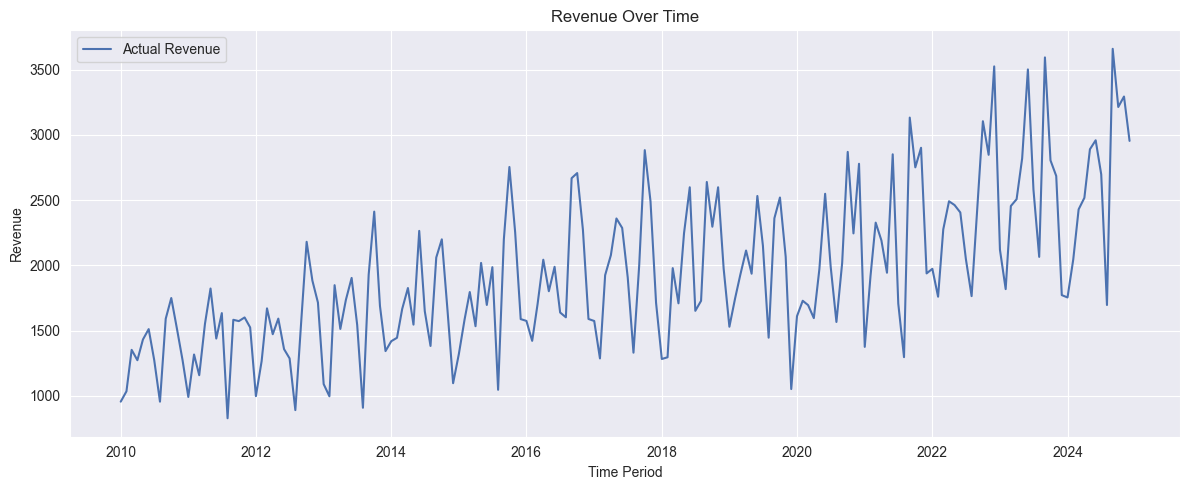

In [172]:
plt.figure(figsize=(12,5))
actual_color = palette[0]

date = pd.to_datetime(df["datekey"].astype(str), format="%Y%m")

plt.plot(date, df["Revenue"], label="Actual Revenue", color=actual_color)

plt.title("Revenue Over Time")
plt.xlabel("Time Period")
plt.ylabel("Revenue")

plt.legend()
plt.tight_layout()
plt.show()


**Initial Visual Inspection and First Impressions of the Time Series**

A preliminary visual inspection of the Revenue time series reveals a clear upward long-term trend, indicating sustained growth over time. The series also exhibits strong and recurring seasonal patterns, with regular peaks and troughs that suggest intra-year cyclicality. Additionally, the amplitude of fluctuations appears to increase over time, pointing to non-constant variance and potential heteroscedasticity. The persistence of high and low values across adjacent periods indicates strong temporal dependence, while shocks appear largely transitory rather than permanent. Overall, the visual evidence strongly suggests that the Revenue series is non-stationary in level, with both the mean and variance changing over time.

#### 3.2.2  Histograms 

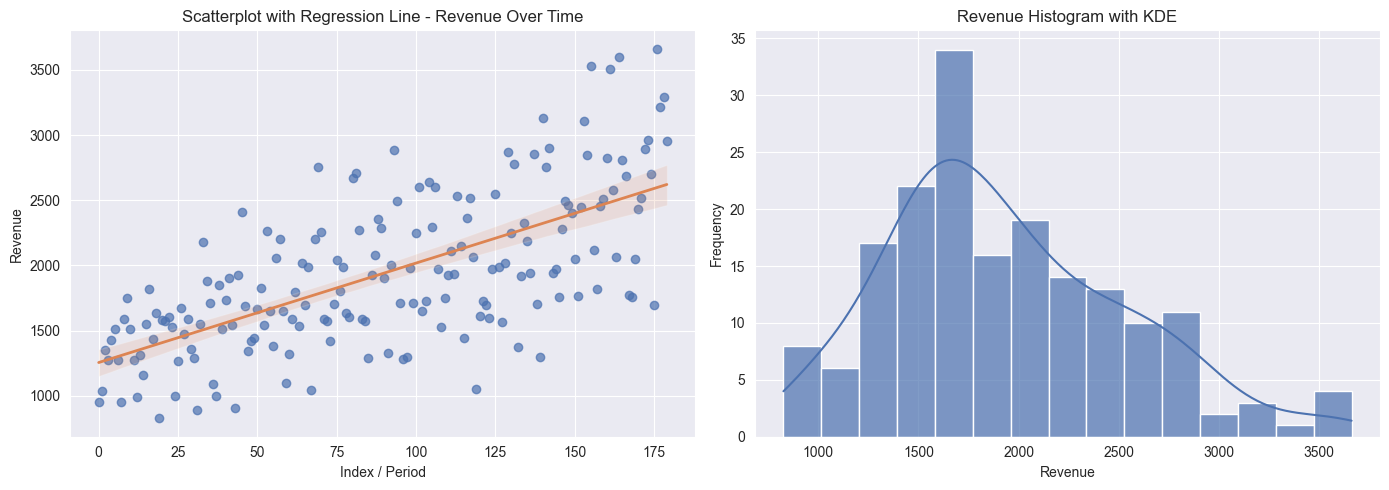

In [173]:
### Revenue Histogram
color = palette[0]      
kde_color = palette[1]  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot + Regression Line
sns.regplot(
    x=reg.index,
    y=reg["Revenue"],
    ax=axes[0],
    scatter_kws={'alpha': 0.7, 'color': color},
    line_kws={'color': kde_color, 'linewidth': 2}
)
axes[0].set_title("Scatterplot with Regression Line - Revenue Over Time")
axes[0].set_xlabel("Index / Period")
axes[0].set_ylabel("Revenue")

# Histogram
sns.histplot(
    reg["Revenue"],
    kde=True,
    bins=15,
    color=color,
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title("Revenue Histogram with KDE")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

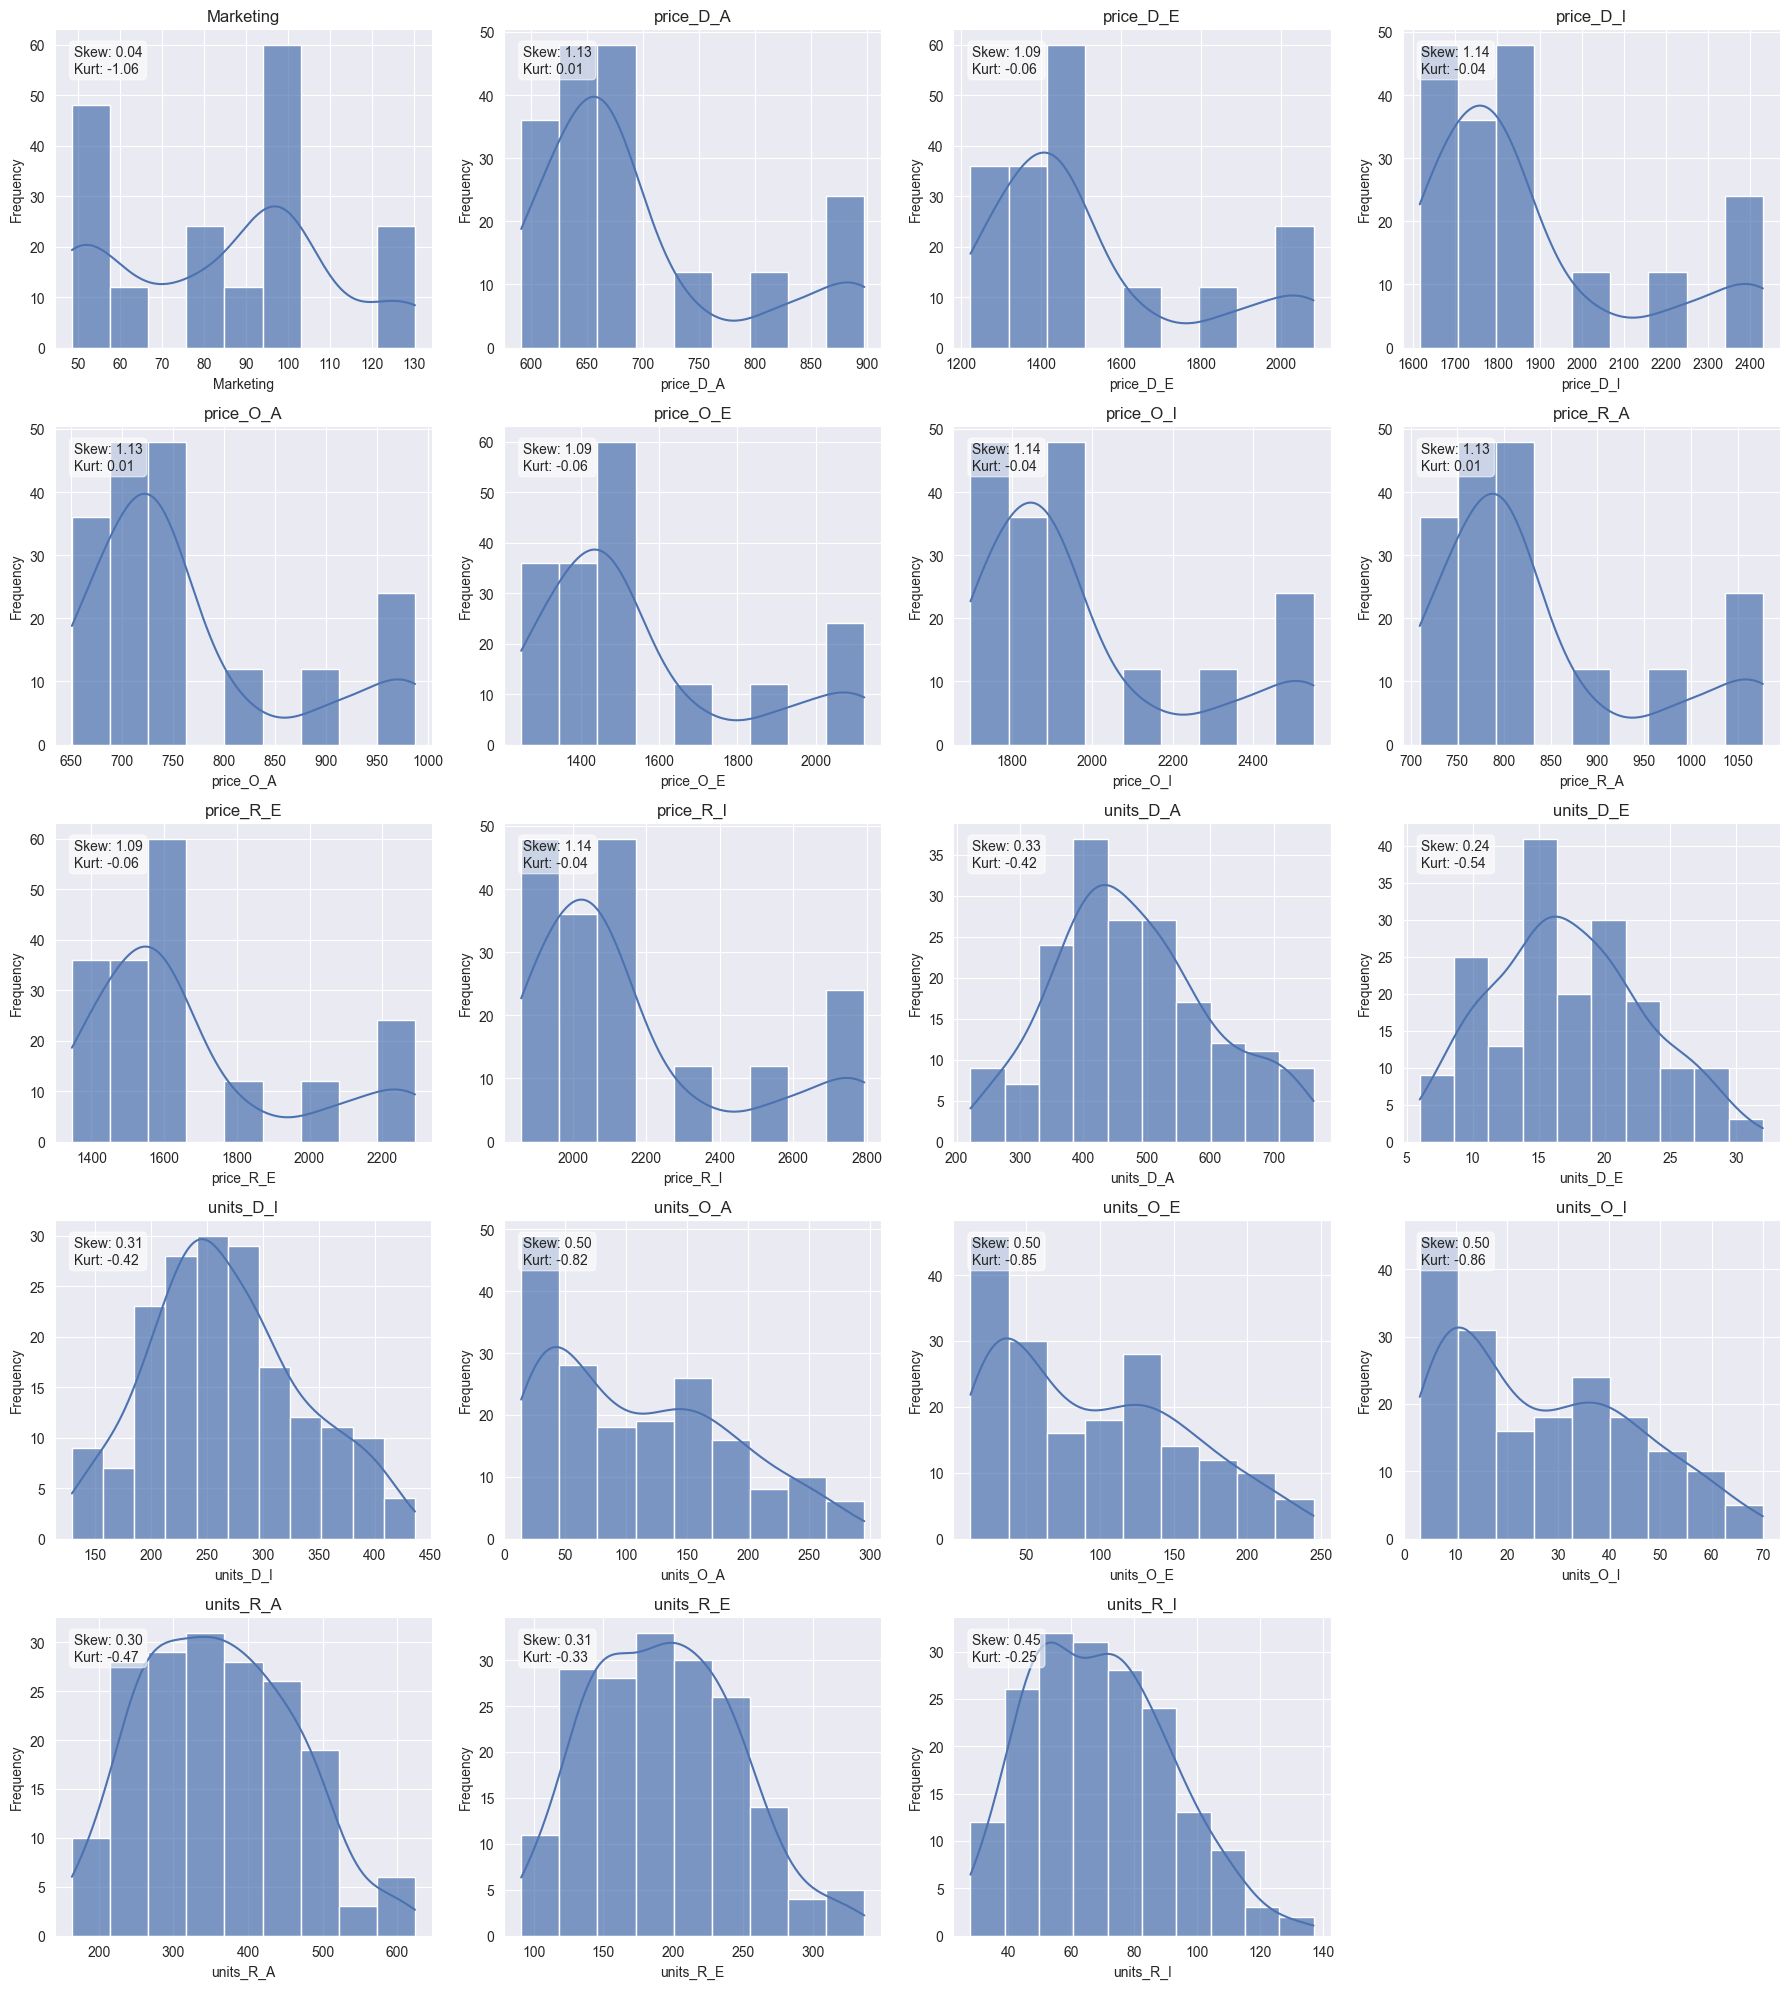

In [174]:
### Features Histograms
X_cols = [col for col in reg.columns if col != "Revenue"]

n_cols = 4
n_rows = (len(X_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

palette = sns.color_palette("deep")
hist_color = palette[0]

for i, col in enumerate(X_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Histogram + KDE
    sns.histplot(
        reg[col],
        kde=True,
        color=hist_color,
        alpha=0.7
    )

    # Compute skewness and kurtosis
    skew_val = reg[col].skew()
    kurt_val = reg[col].kurtosis()

    # Add text inside the plot
    plt.text(
        0.05, 0.95,
        f"Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        fontsize=10,
        bbox=dict(boxstyle="round", fc="white", alpha=0.6)
    )

    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### 3.2.3 Skewness and Kurtosis

In [175]:
# Skewness
skew_values = reg.skew()
# Kurtosis
kurt_values = reg.kurtosis()

# Create combined dataframe
stats_df = pd.DataFrame({
    "Skewness": skew_values,
    "Kurtosis": kurt_values
})

display(stats_df)

# Criteria for approximate normality
normal_mask = (stats_df["Skewness"].between(-0.5, 0.5)) & \
              (stats_df["Kurtosis"].between(-1, 1))

# Lists of variables
normal_variables = stats_df[normal_mask].index.tolist()
non_normal_variables = stats_df[~normal_mask].index.tolist()

print("\n=== Variables Meeting BOTH Normality Criteria ===")
print(normal_variables)

,Skewness,Kurtosis
Revenue,0.603154,0.018272
Marketing,0.039550,-1.058264
price_D_A,1.133044,0.014842
price_D_E,1.089973,-0.058518
price_D_I,1.136074,-0.041430
price_O_A,1.133045,0.014783
price_O_E,1.089968,-0.058522
price_O_I,1.136076,-0.041440
price_R_A,1.133057,0.014848
price_R_E,1.089961,-0.058526



=== Variables Meeting BOTH Normality Criteria ===
['units_D_A', 'units_D_E', 'units_D_I', 'units_O_E', 'units_R_A', 'units_R_E', 'units_R_I']


Skewness and Kurtosis

**Skewness** measures the *asymmetry* of a distribution.  
- A perfectly normal distribution has **skewness = 0**.  
- Positive skew → long right tail (right-leaning).  
- Negative skew → long left tail (left-leaning).  
- In practice, values between **−0.5 and +0.5** indicate an approximately normal distribution.

**Kurtosis** measures the *tailedness* or how heavy/light the tails of a distribution are.  
- Normal distribution → **kurtosis = 0**  
- Positive kurtosis → heavy tails and sharp peak (leptokurtic).  
- Negative kurtosis → light tails and flatter peak (platykurtic).  
- Values between **−1 and +1** are typically considered close to normal.

Skewness and kurtosis help evaluate **whether a variable is approximately normally distributed**, which matters because:
- Many statistical tests assume normality.
- Linear regression assumes normally distributed residuals.
- Non-normality may indicate outliers or structural issues in the data.

#### 3.2.4 Boxplot

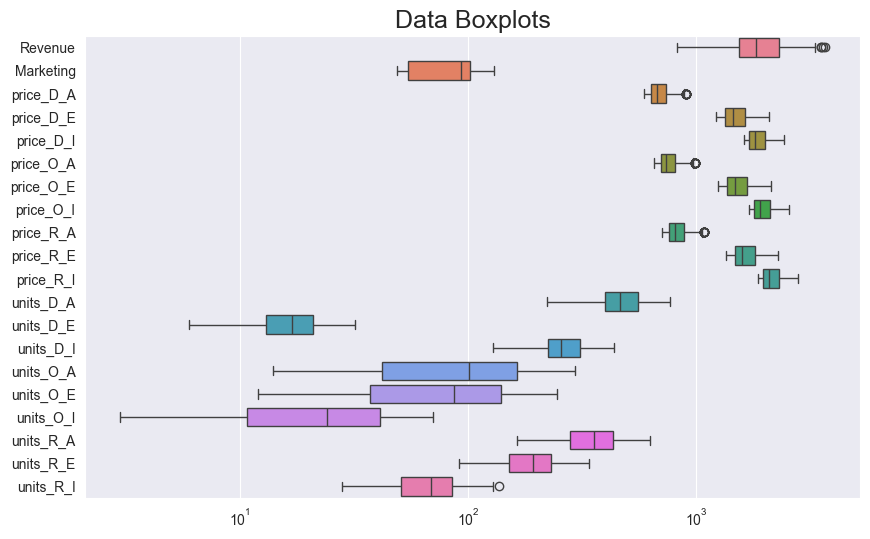

In [176]:
plt.figure(figsize = (10,6))
ax =sns.boxplot(data = reg, orient="h")
ax.set_title('Data Boxplots', fontsize = 18)
ax.set(xscale="log")
plt.show()

#### 3.2.5 Outlier Detection - Z-score

In [177]:
from scipy.stats import zscore
zscores = pd.DataFrame(np.abs(zscore(reg)))
row_mask = (zscores > 3).any(axis=1) # zscores > 3 standard deviations

outlier_vars = zscores[row_mask].loc[:, (zscores[row_mask] > 3).any()]
outlier_vars


,units_R_I
45,3.06547


#### 3.2.6 Univariate Analysis – Summary

Revenue and price variables exhibit right-skewed, non-normal distributions, a pattern commonly observed in financial and economic time series due to growth dynamics, trend effects, and seasonality. Unit-related variables, in contrast, display more symmetric distributions and fall within acceptable skewness (−0.5 to +0.5) and kurtosis (−1 to +1) thresholds, indicating greater statistical stability.

Histograms and KDE plots reinforce this distinction: revenue and prices are more dispersed and skewed, while unit variables show smoother, bell-shaped density profiles. These results suggest that unit variables are better suited for models relying on approximate normality, whereas revenue and price variables require transformations or time-series-aware modeling approaches.

**Additional Note on Boxplots and Outlier Detection.**  
Log-scaled boxplots indicate broadly consistent dispersion across variables and highlight a single extreme observation. Z-score analysis confirms one true outlier exceeding the ±3 standard deviation threshold across multiple features.


### 3.3 Revenue Normality Tests 

#### 3.3.1 Jarque–Bera Test

In [178]:
from statsmodels.stats.stattools import jarque_bera
jb_stat, jb_p, skew, kurtosis = jarque_bera(reg["Revenue"])
print("JB Statistic:", jb_stat)
print("p-value:", jb_p)
print("Skewness:", skew)
print("Kurtosis:", kurtosis)


JB Statistic: 10.734067830287408
p-value: 0.004667956351669198
Skewness: 0.5981163063085242
Kurtosis: 2.9846188248267005


The Jarque–Bera (JB) test evaluates whether a variable follows a normal distribution by examining its **skewness** and **kurtosis**. A normally distributed variable should have:

- **Skewness = 0**  
- **Kurtosis = 3** (excess kurtosis = 0)

The JB test compares the observed skewness/kurtosis with the expected values under normality.

A **small p-value (p < 0.05)** indicates that the distribution **significantly deviates from normality**, leading us to reject the null hypothesis.

**Null hypothesis (H₀):** The data are normally distributed  
**Alternative hypothesis (H₁):** The data are not normally distributed  

Because the **p-value < 0.05**, we **reject H₀** and conclude that 
- **The variable *Revenue* does not follow a normal distribution.**  
- Skewness > 0 indicates **right-tailed asymmetry**.  
- Kurtosis ≈ 3 (excess kurtosis ≈ 0) suggests **near-normal tail weight**, but the skew is enough to break normality.

#### 3.3.2 shapiro Test

In [179]:
from scipy.stats import shapiro

stat, p_value = shapiro(reg["Revenue"])
print("Shapiro-Wilk Test:")
print("Statistic:", stat)
print("p-value:", p_value)


Shapiro-Wilk Test:
Statistic: 0.9678942185758446
p-value: 0.00036827157080758873


The Shapiro–Wilk test is one of the most powerful statistical tests for detecting departures from normality. It evaluates whether the data come from a normally distributed population.

A **small p-value (p < 0.05)** indicates that the data **do not follow a normal distribution**.

**Null hypothesis (H₀):** The data are normally distributed  
**Alternative hypothesis (H₁):** The data are not normally distributed  

Because the **p-value < 0.05**, we **reject H₀** and conclude:

- **Revenue is not normally distributed**, consistent with the Jarque–Bera result.  
- The high significance level (very low p-value) shows a strong deviation from normality.

Shapiro–Wilk is particularly sensitive to asymmetry, which aligns with the skewness observed in Revenue.

#### 3.3.3 Revenue Q–Q Plot

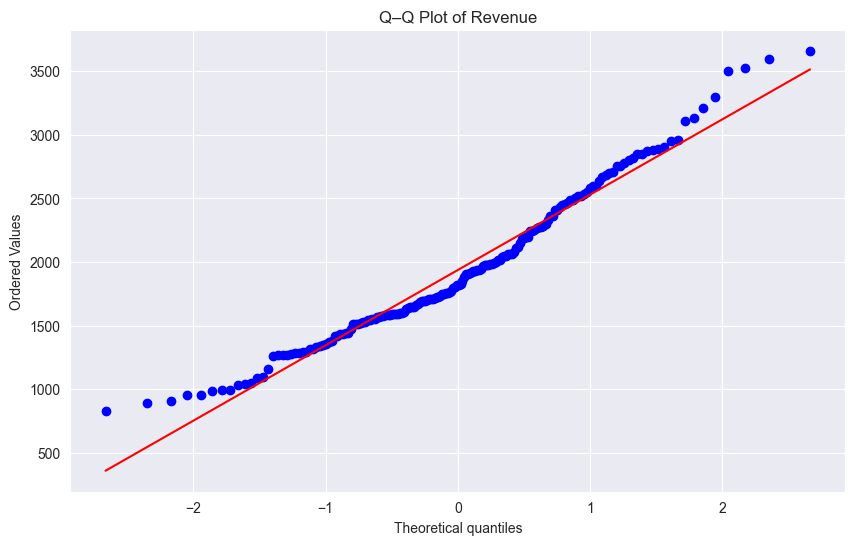

In [180]:
import scipy.stats as stats

plt.figure(figsize=(10, 6))
stats.probplot(reg["Revenue"], dist="norm", plot=plt)
plt.title("Q–Q Plot of Revenue")
plt.show()


A Q–Q (Quantile–Quantile) plot visually assesses whether a variable follows a normal distribution. If the data are normally distributed, the sample quantiles should fall **along the red 45° reference line**.

The plot shows clear deviations from the reference line:

- The **lower tail** (left side) falls **above** the line  
- The **upper tail** (right side) rises **above** the line  
- The curvature indicates a **systematic departure from normality**  
- Extreme right-side points show **positive skewness**, consistent with the numerical results

#### 3.3.4 Revenue Normality Tests - Summary

All normality tests and visual inspections consistently indicate that Revenue does not follow a normal distribution, exhibiting right skewness and mild heavy-tail behavior. Normality-based methods (e.g., OLS inference) may be unreliable without transformation.

This visual evidence aligns with the earlier statistical tests:

- **Jarque–Bera test:** p-value = 0.0047 → reject H₀ (not normal)  
- **Shapiro–Wilk test:** p-value = 0.00037 → reject H₀ (not normal)  
- **Skewness:** +0.598 → right-skewed  
- **Kurtosis:** 2.98 → moderate tail weight

**Conclusion**

All pieces of evidence (JB test, Shapiro–Wilk, skewness/kurtosis, and the Q–Q plot) consistently indicate that:

- **Revenue does not follow a normal distribution.**  
- The distribution is **positively skewed** with slight heavy tails.  
- Normality assumptions for methods like OLS or t-tests may be violated.

**Note:** Normality of the Revenue variable itself is not a requirement for time-series forecasting or for OLS point estimation. The relevant assumption for classical OLS inference concerns the distribution of the regression residuals (and, in time-series models, the innovation process). Therefore, the non-normality of Revenue primarily motivates considering transformations and residual-level diagnostics in the final fitted models.

### 3.4 Bivariate Analysis (Revenue × Drivers)

#### 3.4.1 Linear Correlation-Based Relationships - Pearson Correlation

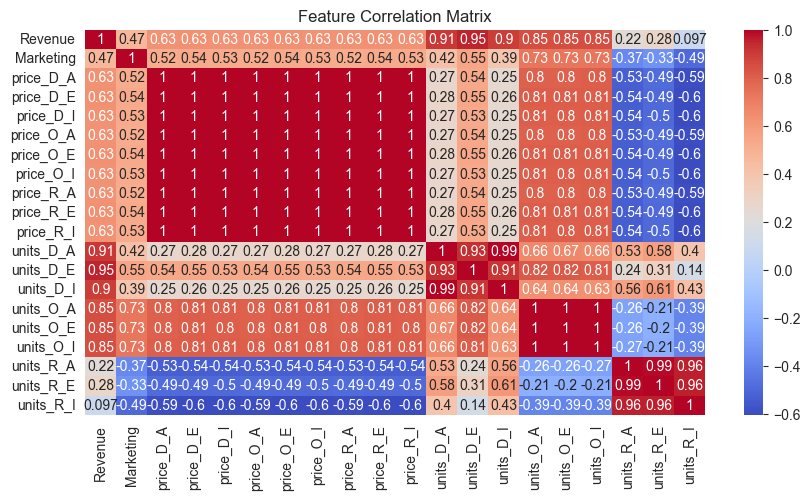

In [181]:
plt.figure(figsize=(10, 5))
sns.heatmap(reg.corr(numeric_only=True, method="pearson"), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [182]:
# Compute correlation of all features with the target variable "Revenue"
target_correlation = reg.corr(numeric_only=True, method="pearson")["Revenue"].sort_values()
target_correlation

units_R_I    0.097493
units_R_A    0.224141
units_R_E    0.281660
Marketing    0.473143
price_O_A    0.629057
price_R_A    0.629057
price_D_A    0.629058
price_O_I    0.629191
price_D_I    0.629191
price_R_I    0.629192
price_D_E    0.633651
price_O_E    0.633651
price_R_E    0.633652
units_O_I    0.850957
units_O_E    0.853355
units_O_A    0.854127
units_D_I    0.897904
units_D_A    0.906579
units_D_E    0.951357
Revenue      1.000000
Name: Revenue, dtype: float64

#### 3.4.2 Monotonic Correlation-Based Relationships – Spearman Rank

The Spearman rank correlation coefficient measures **monotonic relationships between variables**, capturing whether one variable consistently increases or consistently decreases as the other changes, regardless of whether the relationship is linear or non-linear in form. Unlike Pearson correlation, which is limited to **linear** associations, Spearman evaluates the direction and strength of a relationship even when it follows a curved or non-linear pattern.

This makes Spearman correlation particularly useful when:

- The variables are not normally distributed  
- Outliers are present  
- The relationship between variables is monotonic but not linear  
- Pearson correlation may underestimate or fail to capture the association  

In our analysis, Spearman correlation illustrates how each predictor moves together with *Revenue*, even when the underlying pattern is non-linear. Strong monotonic correlations suggest potential predictive relevance, even when the linear assumptions of Ordinary Least Squares (OLS) do not fully hold.

A **monotonic relationship** in statistics refers to a relationship in which, as one variable increases, the other consistently increases or consistently decreases, without ever changing direction.


In [183]:
spearman_corr = reg.corr(method="spearman")["Revenue"].sort_values(ascending=False)
spearman_corr

Revenue      1.000000
units_D_E    0.959278
units_D_A    0.921659
units_D_I    0.910035
units_O_E    0.838728
units_O_I    0.838621
units_O_A    0.837892
price_R_E    0.659652
price_R_I    0.659652
price_O_I    0.659652
price_O_E    0.659652
price_D_I    0.659652
price_D_E    0.659652
price_R_A    0.658235
price_O_A    0.658235
price_D_A    0.658235
Marketing    0.532020
units_R_E    0.269145
units_R_A    0.213475
units_R_I    0.074776
Name: Revenue, dtype: float64

#### 3.4.3 Non-Linear and Predictive Importance – Random Forest Feature Importance

Random Forest feature importance quantifies each predictor’s **marginal contribution to predictive performance** in a **multivariate, non-linear** model. Unlike correlation metrics, it captures **non-linear effects and interactions** learned by the ensemble, reflecting **predictive relevance** rather than pairwise association. Importance can be computed via **impurity-based (MDI)** scores or **permutation importance**, with permutation generally providing a more reliable estimate of out-of-sample contribution.


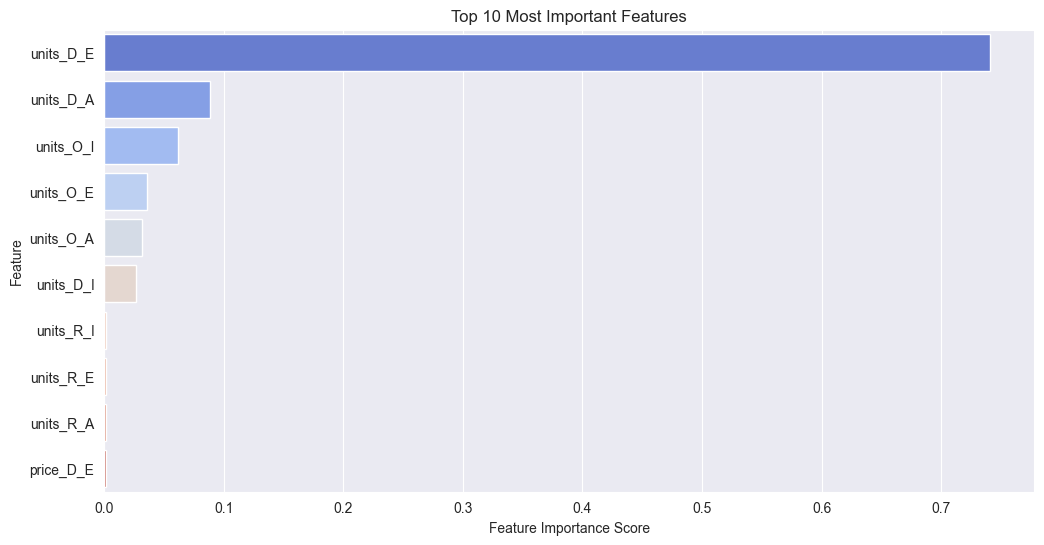

,Feature,Importance
0,units_D_E,0.740657
1,units_D_A,0.088657
2,units_O_I,0.062089
3,units_O_E,0.035902
4,units_O_A,0.031385
5,units_D_I,0.027047
6,units_R_I,0.001815
7,units_R_E,0.001643
8,units_R_A,0.001527
9,price_D_E,0.001341


In [184]:
from sklearn.ensemble import RandomForestRegressor

# Define features and target variable
X = reg.drop(columns=["Revenue"])
y = reg["Revenue"]

# Train a Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance[:10], y=feature_importance.index[:10], palette="coolwarm")
plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()

# Print as table
feature_df = feature_importance.to_frame().reset_index()
feature_df.columns = ["Feature", "Importance"]
feature_df


#### 3.4.4 Scatterplots with Regression Line - Revenue vs Independent Variables
Visual Confirmation of Economic Relationships.

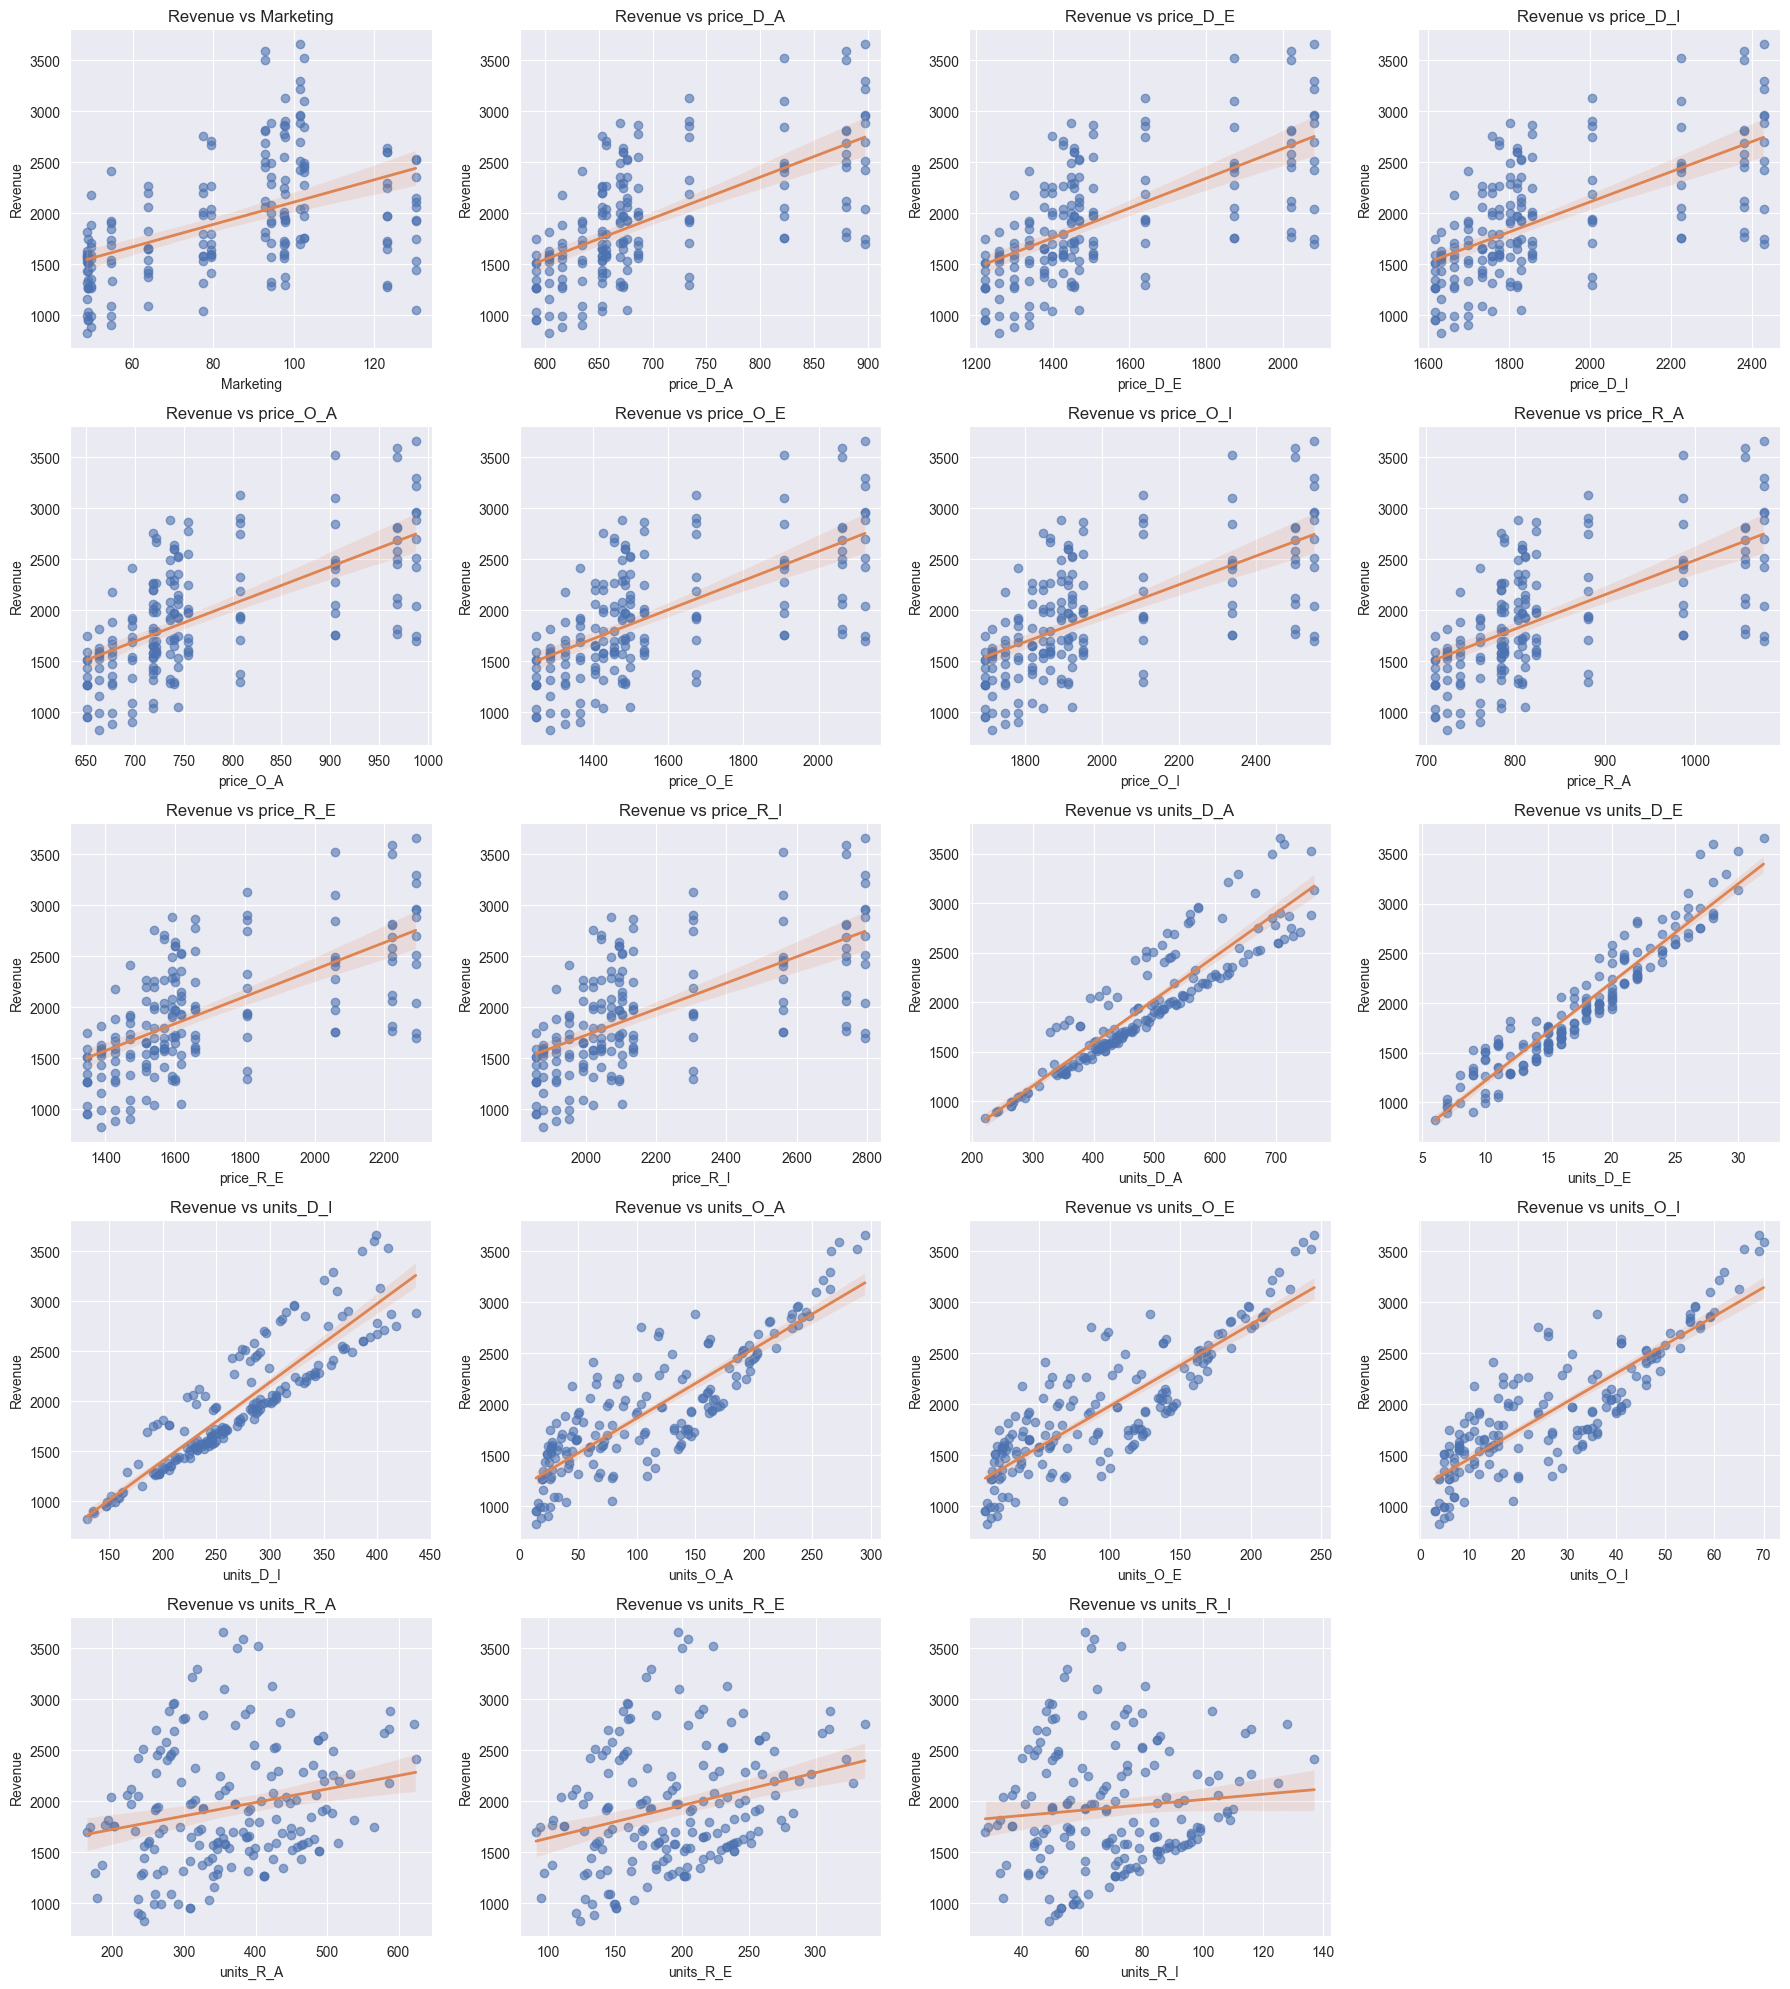

In [185]:
# Variables
X_cols = [col for col in reg.columns if col != "Revenue"]

# Grid layout
n_cols = 4
n_rows = (len(X_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

scatter_color = palette[0]      
regline_color = palette[1]     

for i, col in enumerate(X_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    sns.regplot(
        x=reg[col],
        y=reg["Revenue"],
        scatter_kws={'alpha': 0.6, 'color': scatter_color},
        line_kws={'color': regline_color, 'linewidth': 2}
    )
    
    plt.title(f"Revenue vs {col}")
    plt.xlabel(col)
    plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

#### 3.4.5 Bivariate Analysis (Revenue × Drivers) – Summary

The bivariate analysis highlights clear and consistent relationships between *Revenue* and its main drivers. **Unit sales variables** exhibit the strongest associations with Revenue, showing high Pearson and Spearman correlations and near-linear monotonic patterns in scatter plots, indicating they are primary revenue drivers. **Price-related variables** display moderate positive correlations, suggesting a stable but less dominant contribution. **Marketing** shows weaker to moderate monotonic relationships, indicating indirect or complementary effects.

Spearman correlations confirm that most key drivers relate to Revenue in a **monotonic manner**, even when linear assumptions may not strictly hold. Random Forest feature importance further reinforces these findings by identifying unit-based variables as the most **predictively relevant**, capturing non-linear effects and interactions not reflected in correlation metrics alone.

Overall, the results show strong alignment between correlation-based insights and model-based importance, supporting the robustness of the identified Revenue drivers.


### 3.5 Regularized Feature Selection under Multicollinearity


#### 3.5.1 RFE — Recursive Feature Elimination

Recursive Feature Elimination (RFE) is a wrapper-based feature selection method that iteratively removes the least important predictors based on a chosen machine learning model (in our case, a Linear Regression model).

The algorithm works by:

- Fitting a regression model to all predictors  
- Ranking features by their importance (coefficient magnitude)  
- Removing the weakest feature  
- Repeating the process until the desired number of features is reached  

**Interpretation caveat:** Under severe multicollinearity, RFE with OLS-based ranking can become selection-unstable, often choosing a subset of variables that act as proxies for a correlated block rather than the “true” dominant drivers. Therefore, RFE results should be interpreted as dimensionality reduction and not as evidence of economic dominance; regularized methods (ElasticNet) and out-of-sample validation remain preferred for stable conclusions.

In [186]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Separate predictors and target
X = reg.drop(columns=["Revenue"])
y = reg["Revenue"]

# Base model for RFE
model = LinearRegression()
n_features = 8  

# Fit RFE
rfe = RFE(estimator=model, n_features_to_select=n_features)
rfe.fit(X, y)

selected = pd.Series(rfe.support_, index=X.columns)
ranking = pd.Series(rfe.ranking_, index=X.columns)

print("Selected features:")
print(selected[selected == True].index)

print("\nFeature ranking:")
print(ranking.sort_values())

Selected features:
Index(['price_D_A', 'price_D_E', 'price_D_I', 'price_O_A', 'price_O_I',
       'price_R_A', 'price_R_E', 'price_R_I'],
      dtype='object')

Feature ranking:
price_R_I     1
price_D_A     1
price_D_E     1
price_D_I     1
price_O_A     1
price_O_I     1
price_R_A     1
price_R_E     1
price_O_E     2
units_R_I     3
units_O_A     4
units_D_I     5
units_D_E     6
units_D_A     7
units_O_I     8
units_O_E     9
Marketing    10
units_R_E    11
units_R_A    12
dtype: int32


#### 3.5.2 LassoCV

LassoCV is a regression technique that combines **L1 regularization** with **cross-validation** to perform both prediction and feature selection simultaneously.

The LASSO penalty forces less important coefficients toward zero, and some become exactly zero, effectively removing those predictors from the model. Unlike RFE, LassoCV produces:

- A fully estimated regression model  
- A set of automatically selected features (non-zero coefficients)  
- A regularization strength `alpha` chosen through cross-validation  

In [187]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Separate predictors and target
X = reg.drop(columns=["Revenue"])
y = reg["Revenue"]

# Scale predictors (LASSO needs scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit LassoCV
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

# Coefficients
coef = pd.Series(lasso.coef_, index=X.columns)

print("Best alpha:", lasso.alpha_)
print("\nSelected features (non-zero coefficients):")
print(coef[coef != 0])

Best alpha: 0.564510637459697

Selected features (non-zero coefficients):
Marketing    -65.542337
price_D_A    198.140634
price_O_A      9.850727
price_R_A      0.326965
units_D_A     95.615084
units_D_E     50.358178
units_D_I    134.965339
units_O_A    160.485397
units_O_I     74.364593
units_R_A    142.737236
units_R_E      0.773290
dtype: float64


#### 3.5.3 ElasticNetCV

ElasticNet is a **regularized linear regression model** that combines the strengths of **LASSO (L1)** and **Ridge (L2)** penalties. It is specifically designed for settings with **high-dimensional data and multicollinearity**, where many predictors are strongly correlated. Unlike pure LASSO, ElasticNet tends to **retain groups of correlated variables** rather than arbitrarily selecting only one, producing **more stable and economically interpretable coefficients**.

In this project, ElasticNet is used **exclusively as a driver interpretation tool**, not as a forecasting model.  

Key design choices reflect this objective:

- Lagged revenue variables and engineered transformations are excluded to avoid leakage.
- Coefficients represent **contemporaneous economic relationships** between Revenue and its drivers.
- Time-series dynamics (trend, seasonality, persistence) are handled separately by ARIMA/SARIMA models.

As such, ElasticNet complements the time-series models by answering: *Which business drivers explain the level of Revenue, and in what direction?*

In [188]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

elas = df.copy()
elas.drop(columns= ['datekey','Trend', 'Revenue_t1', 'Revenue_lag1', 'Revenue_lag12', 'Revenue_diff', 'Revenue_yoy_diff', 'Revenue_pct_change', 'Revenue_detrended'], inplace = True)

y = elas["Revenue"]
X = elas.drop(columns="Revenue")

tscv = TimeSeriesSplit(n_splits=5)

elastic_net = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=None,
        cv=tscv,
        max_iter=10000
    ))
])

elastic_net.fit(X, y)

coef = pd.Series(
    elastic_net.named_steps["model"].coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

coef

units_D_I    101.143893
units_D_A     94.635620
units_R_A     78.168707
units_O_I     75.165773
units_O_A     74.846130
units_O_E     72.873586
units_R_E     64.063048
units_D_E     63.675479
Marketing    -45.524561
price_D_I     27.420369
price_O_I     27.212715
price_R_I     26.996360
price_O_A     26.626976
price_D_A     26.327577
price_R_A     26.254737
units_R_I     24.556826
price_O_E     19.456773
price_D_E     19.401978
price_R_E     19.074938
dtype: float64

#### 3.5.4 Regularized Feature Selection – Conclusions

The three feature selection approaches (RFE, LassoCV, and ElasticNetCV) yield partially different rankings because they answer **distinct analytical questions** under multicollinearity.

**RFE (Linear Regression–based)** prioritizes variables that best explain *Revenue* within a purely linear framework. Under strong multicollinearity, RFE tends to retain **price variables**, as they provide stable linear explanatory power when evaluated jointly, even if they are proxies for underlying demand effects.

**LassoCV (L1 regularization)** performs simultaneous estimation and feature selection by shrinking coefficients toward zero. In correlated feature groups, Lasso arbitrarily selects a subset, which in this case emphasizes **price and marketing variables**, reflecting their ability to explain variance once unit variables compete within the same correlated space.

**ElasticNetCV (L1 + L2 regularization)** explicitly addresses multicollinearity by distributing weight across correlated predictors. As a result, it consistently highlights **unit-based variables** as the dominant drivers, aligning more closely with the bivariate analysis and Random Forest feature importance.

Importantly, the apparent disagreement between methods is **not contradictory**, but **diagnostic**:
- Price variables are strong **linear correlates** and survive aggressive regularization.
- Unit variables capture the **structural demand signal**, emerging clearly when multicollinearity is handled more smoothly (ElasticNet, Random Forest).
- No single method should be interpreted in isolation.

From an interpretability standpoint, **ElasticNetCV provides the most economically coherent view of revenue drivers**, while RFE and LassoCV serve as robustness checks. Overall, the combined evidence supports unit-based drivers as the primary determinants of Revenue, with prices and marketing acting as secondary, complementary factors.


### 3.6 Multicollinearity (VIF- Variance Inflation Factor)

In [189]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_const = sm.add_constant(X)

vif_data = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"]
vif_data

,Feature,VIF
1,Marketing,1.460503e+01
2,price_D_A,4.270408e+09
3,price_D_E,3.468296e+10
4,price_D_I,1.018511e+11
5,price_O_A,9.583004e+09
6,price_O_E,1.045671e+11
7,price_O_I,2.047929e+11
8,price_R_A,1.694344e+10
9,price_R_E,1.265785e+11
10,price_R_I,6.074658e+10


Multicollinearity occurs when two or more independent variables in a dataset are highly correlated, leading to redundancy and instability in predictive models. It can inflate variance, making coefficient estimates unreliable, and negatively impacting the interpretability and performance of machine learning models. This process helps improve model stability, avoids redundancy, and enhances predictive accuracy.

**Variance Inflation Factor (VIF) Interpretation**
To detect multicollinearity, we use the Variance Inflation Factor (VIF). The accepted thresholds are:

- **VIF < 5** → No concerning multicollinearity (Safe to keep the variable)
- **VIF between 5 and 10** → Moderate multicollinearity (May require evaluation)
- **VIF > 10** → High multicollinearity (Variable might be redundant and should be removed)

By analyzing VIF values, we can systematically eliminate highly correlated features, ensuring a more stable and interpretable model.

The Variance Inflation Factor (VIF) analysis shows extremely high multicollinearity among the predictors. Most features present VIF values far above the threshold of 10, with several reaching values in the order of 10¹⁰–10¹¹.  

Given the magnitude of multicollinearity, coefficient interpretation under OLS becomes unreliable even if residual diagnostics appear acceptable.

### 3.7 Variance Analysis

In [190]:
### Low Variance Features
feature_variances = reg.var()
low_variance_features = feature_variances[feature_variances < 1e-2]  
print("Features with very low variance:", low_variance_features.index.tolist())

Features with very low variance: []


What is the most commonly used variance threshold?

The threshold value depends on the type of data in the dataset:

| Threshold (`limiar`) | When to use? | Impact |
|--------------------------|------------------|-------------|
| `0.0` *(default in Scikit-Learn)* | Keeps all variables, even those with very low variance. | No removal. |
| **`0.01`** *(most common standard)* | Removes variables that change very little and are not informative. | Recommended in most cases. |
| `0.05` | If the dataset has many variables and some are almost constant. | Removes variables with small variations. |
| `0.1` or higher | If there are many features and a suspicion of redundant variables. | Can be too aggressive. |

**Summary**

The variance analysis shows that none of the features fall below the low-variance threshold (1e-2). This means all predictors exhibit sufficient variability and no feature should be removed based solely on variance filtering.


### 3.8 PCA - Exploratory dimensionality diagnostic

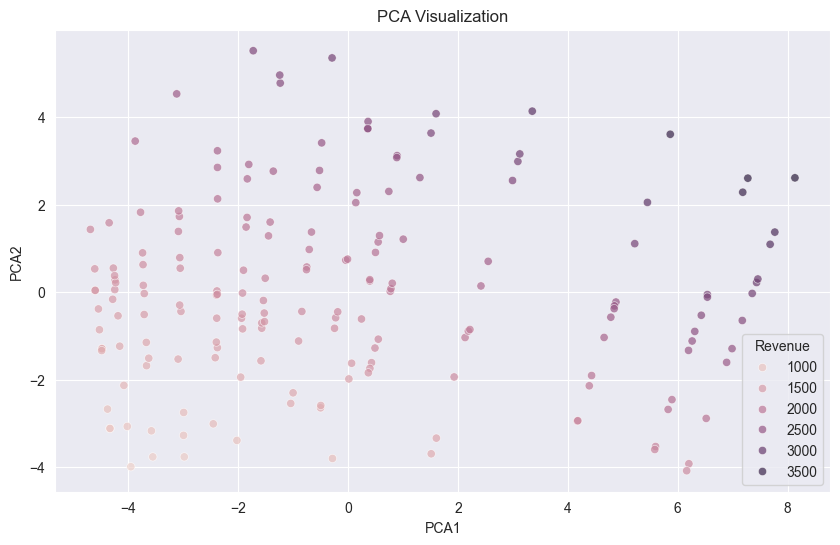

In [191]:
# Standardize features before PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_features = scaler.fit_transform(reg.drop(columns=["Revenue"]))

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Convert to DataFrame
df_pca = pd.DataFrame(pca_result, columns=["PCA1", "PCA2"])
df_pca["Revenue"] = reg["Revenue"]

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Revenue", data=df_pca, alpha=0.7)
plt.title("PCA Visualization")
plt.show()

In [192]:
# Retrieve the PCA component loadings (how features contribute to each principal component)
pca_loadings = pd.DataFrame(pca.components_, columns=reg.drop(columns=["Revenue"]).columns, index=["PCA1", "PCA2"])
print(pca_loadings.T)  

               PCA1      PCA2
Marketing  0.182948  0.057712
price_D_A  0.270552 -0.046786
price_D_E  0.271768 -0.044586
price_D_I  0.271212 -0.048076
price_O_A  0.270552 -0.046787
price_O_E  0.271768 -0.044586
price_O_I  0.271212 -0.048077
price_R_A  0.270551 -0.046786
price_R_E  0.271768 -0.044586
price_R_I  0.271212 -0.048076
units_D_A  0.108065  0.429266
units_D_E  0.176957  0.345421
units_D_I  0.100697  0.434470
units_O_A  0.250135  0.150771
units_O_E  0.249716  0.151180
units_O_I  0.250524  0.147546
units_R_A -0.141656  0.380373
units_R_E -0.128014  0.398513
units_R_I -0.165593  0.337642


PCA Visualization 

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional space while preserving as much variance as possible. It works by identifying the **principal components** (linear combinations of original features) that explain the most variability in the dataset.

**In this case:**
- Standardization (StandardScaler) was applied before PCA to ensure all features are on the same scale.
- PCA was used to reduce the dataset to 2 components (`PCA1` and `PCA2`), allowing for visualization in a 2D space.


**Analyzing Feature Importance in the Original Space**
    
Since PCA transforms the original features into new components, we lose interpretability of individual feature contributions. To regain this, we can:

- Check the PCA Component Loadings (Eigenvectors)
- These tell us how much each original feature contributes to PCA1 and PCA2.
- The values in the PCA loadings matrix indicate how much each original feature influences each principal component.
- These values are not correlation coefficients, but rather weights showing how much variance of a feature is captured by PCA1 and PCA2.
- Large absolute values mean the feature contributes strongly to PCA, but not necessarily to Revenue prediction.
- To understand feature relevance for Revenue, use correlation or feature importance from models like Random Forest.

Features with high absolute values in a principal component are more influential.

**Summary**

PCA1:
- Primarily driven by price variables, and several unit-related features.
- Represents the overall magnitude or scale of the dataset, reflecting global growth patterns and shared movements across variables.

PCA2:
- Mainly influenced by unit variables, with a mix of positive and negative loadings.
- Captures cross-channel and cross-product variations that are orthogonal to the main trend and do not strongly relate to overall revenue levels.

#### 3.8.1 K-Means Clustering on PCA Data

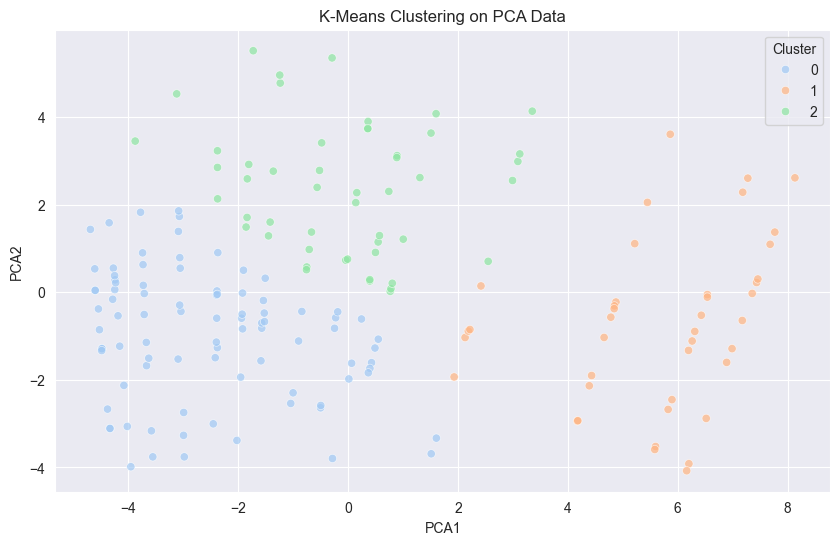

In [193]:
from sklearn.cluster import KMeans

# Apply K-Means clustering on PCA-transformed data
kmeans = KMeans(n_clusters=3, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(pca_result)  # Add cluster labels

# Plot K-Means Clustering (Correcting the Hue Parameter)
plt.figure(figsize=(10,6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df_pca, palette="pastel", alpha=0.7)
plt.title("K-Means Clustering on PCA Data")
plt.show()

K-Means Clustering on PCA Data (Summary)

Applying K-Means to the PCA-transformed data resulted in three clusters.  The segmentation is mainly driven by **PCA1**, which reflects overall magnitude effects (prices, units, and trend).  The clusters separate the data into **low**, **medium**, and **high** magnitude regions rather than revealing any natural or distinct groups.  This confirms that the dataset has a continuous structure without inherent clustering patterns.

Decision implication: PCA confirms that a large share of variance is captured by a small number of components, consistent with the extreme multicollinearity observed in VIF. This supports treating the raw feature space as redundant, discouraging coefficient-level interpretation under OLS and motivating the use of regularization (ElasticNet) for driver interpretation. 

### 3.9 Stationarity - ADF Test (Augmented Dickey-Fuller)

In [194]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(reg["Revenue"])
print(adf_result[1])  # p-value


0.9486849232789631



Stationarity refers to the property of a time series whose statistical characteristics—such as mean, variance, and autocorrelation—remain constant over time. Many time series models (e.g., ARIMA, SARIMA, VAR) require the input data to be stationary to ensure stable parameter estimation, reliable forecasting, and meaningful interpretation. Non-stationary data can lead to misleading patterns, spurious regressions, and poor predictive performance.

Augmented Dickey-Fuller (ADF) Test Interpretation

To evaluate whether a time series is stationary, we use the Augmented Dickey-Fuller (ADF) test. The hypotheses are:

- H₀ (Null Hypothesis): The series has a unit root → The series is NOT stationary

- H₁ (Alternative Hypothesis): The series is stationary

The ADF test on the Revenue series returned a very high p-value (~0.95). Since the p-value is well above the 0.05 significance level, we fail to reject the null hypothesis of non-stationarity. This indicates that the Revenue series is **non-stationary**, meaning its statistical properties (mean, variance, autocorrelation) change over time. Differencing or trend removal may be required for time-series modeling.

#### 3.9.1 STL Time Series Decomposition (Seasonal–Trend–Residual)

<Figure size 1000x800 with 0 Axes>

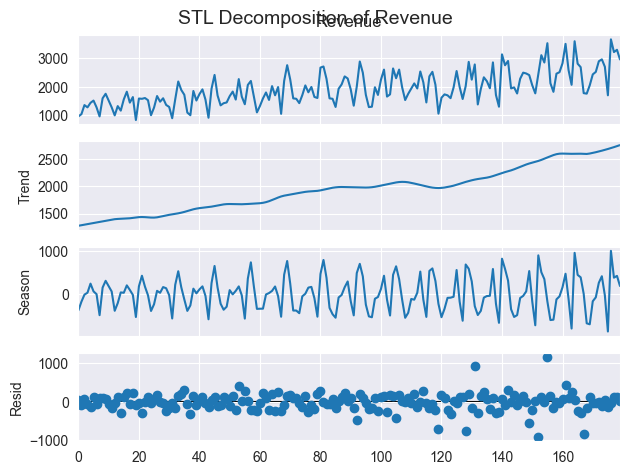

In [195]:
from statsmodels.tsa.seasonal import STL

# Apply STL decomposition
stl = STL(reg["Revenue"], period=12, robust=True)
result = stl.fit()

# Plot decomposition
plt.figure(figsize=(10, 8))
result.plot()
plt.suptitle("STL Decomposition of Revenue", fontsize=14)
plt.show()


STL (Seasonal-Trend decomposition using Loess) is a robust method for decomposing a time series into three interpretable components:

- **Trend:** long-term movement of the series  
- **Seasonal:** repeating patterns within fixed periods  
- **Residual:** noise or unexplained variation  

Unlike classical decomposition methods, STL is highly flexible, handles non-stationary data, and does not assume constant seasonality over time. It is particularly useful for diagnosing structural behavior in a series before applying forecasting or regression models.

In this step, we decompose *Revenue* into its components to better understand underlying trends, detect seasonality, and verify whether the residual behavior aligns with the assumptions used in linear modeling.

**Interpretation of the STL Components**

- **Trend:** Revenue shows a clear and smooth upward trajectory, confirming long-term growth.
- **Seasonal:** A strong repeating seasonal pattern is visible, indicating highly cyclical month-to-month fluctuations consistent throughout the series.
- **Residual:** The residuals appear centered around zero with no major persistent structure, though occasional outliers exist — consistent with prior normality and skewness tests.

Together, these results confirm that *Revenue* contains both structural trend and significant seasonality, explaining the violations observed in the normality and stationarity tests. This reinforces the need to perform transformations or apply time-series-aware modeling when forecasting.

### 3.10 Autocorrelation

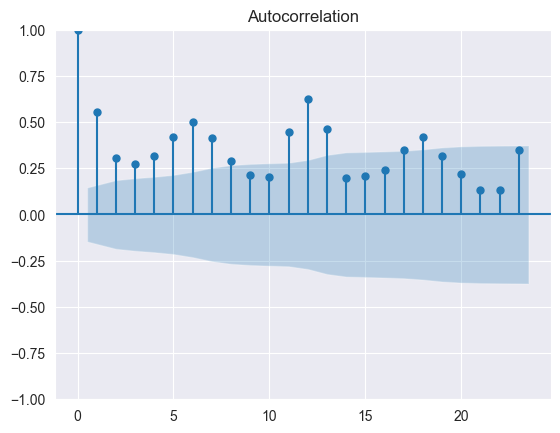

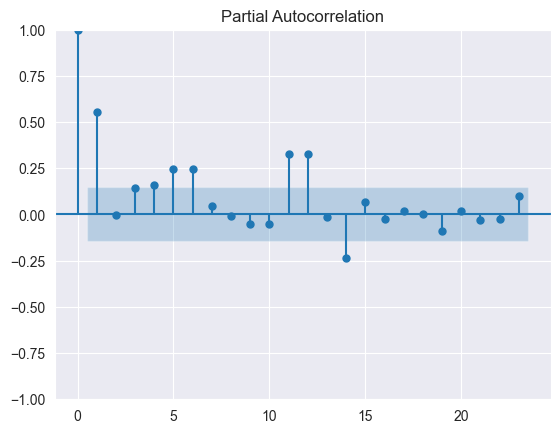

In [196]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(reg["Revenue"])
plt.show()

plot_pacf(reg["Revenue"])
plt.show()


Autocorrelation (ACF) and Partial Autocorrelation (PACF)

The **Autocorrelation Function (ACF)** measures the correlation between a time series and its own past values at different lags. It helps identify overall persistence, seasonality patterns, and how strongly past observations influence future ones.

The **Partial Autocorrelation Function (PACF)** isolates the correlation at a specific lag by removing the influence of all intermediate lags. PACF is useful for identifying the appropriate autoregressive (AR) order in time-series modeling, as it shows the direct effect of lagged values.

- **ACF → overall autocorrelation structure (MA terms, seasonality, persistence).**  
- **PACF → direct lag relationships (AR terms).**

**Summary**

The ACF plot shows strong positive autocorrelation across many lags, confirming that the Revenue series is highly persistent and non-stationary. This aligns with the ADF test, which returned a high p-value.

The PACF shows significant spikes at the first lag (lag 1), indicating that recent past values have a direct influence on Revenue.

Overall, the ACF and PACF plots confirm:
- The series is **non-stationary**.  
- Revenue depends heavily on its recent past.  
- Differencing or detrending would be required for time-series forecasting models.


### 3.11 Exploratory Data Analysis (EDA) – Summary

The EDA reveals clear structural patterns in the dataset, including strong temporal dependence, severe multicollinearity, meaningful volume–revenue relationships, and non-normal, non-stationary behavior of Revenue. Below is a consolidated overview organized according to the structure of Section 3.

3.1 Data Preview & Structure
- The dataset contains 180 monthly observations with consistent feature naming across price, unit, and marketing variables.
- No missing values are present, and data types are correctly inferred for numeric and time-based operations.

3.2 Univariate Analysis
- **Feature Distributions:** Price variables are highly skewed; unit variables show smoother, near-normal distributions; Revenue exhibits right-skewness.
- **Outliers:** Only one extreme outlier (row index 45) was detected using the |z-score| > 3 criterion, indicating overall stability.
- **Scale Differences:** Strong variation in scale across features (prices ≫ units ≫ marketing), justifying normalization or scaling prior to regression.

3.3 Revenue Normality Tests

- **3.3.1 Jarque–Bera Test:** Strongly rejects normality due to positive skewness and tail behavior.
- **3.3.2 Shapiro–Wilk Test:** Reports a very low p-value, confirming non-normality.
- **3.3.3 Q–Q Plot:** Shows clear deviation from the 45° line, especially in the upper tail.

**Conclusion:** Revenue is *not* normally distributed, limiting standard OLS inference without adjustments.

3.4 Bivariate Analysis (Revenue × Drivers)
- **Pearson Correlation:** Unit variables exhibit the strongest linear associations with Revenue, while price and marketing effects are weaker.
- **Spearman Correlation:** Strong monotonic relationships confirm that unit drivers consistently move with Revenue even when linear assumptions may not hold.
- **Random Forest:** Unit-based features dominate predictive importance, capturing non-linear effects and interactions.
**Conclusion:** All methods converge—Revenue is primarily volume-driven rather than price-driven.

3.5 Regularized Feature Selection under Multicollinearity
- **LassoCV:** Retains a sparse subset of predictors, including key unit variables alongside selected price and marketing components.
- **RFE:** Selects more price variables due to multicollinearity, but still ranks unit-related features as important.
- **Scatterplots:** Confirm visually strong linear relationships between units and Revenue, with weaker signals from price and marketing.

3.6 Multicollinearity (VIF)
- VIF values exceed 10⁸–10¹¹ for most predictors, indicating *extreme* multicollinearity.
- OLS coefficients become unreliable and highly unstable under such conditions.

3.7 Variance Analysis
None of the features fall below the low-variance threshold (1e-2). This means all predictors exhibit sufficient variability and no feature should be removed based solely on variance filtering.

3.8 PCA (Principal Component Analysis)
- **PCA1:** Captures global magnitude effects driven by prices, units, and trend.
- **PCA2:** Captures cross-channel variation mainly influenced by unit variables.
- PCA scatterplots reveal smooth gradients rather than clusters, indicating structural continuity.

3.9 Stationarity (ADF Test)
- ADF p-value ≈ 0.95 → fail to reject the null hypothesis of a unit root.
- Revenue is *non-stationary*, dominated by trend and persistence.

3.10 Autocorrelation (ACF & PACF)
- ACF shows strong and slow-decaying autocorrelation.
- PACF exhibits significant spikes at lag 1 and lag 2, resembling an AR(2) structure.
- Revenue has strong temporal dependence requiring time-series modeling.

Overall Conclusions & Modeling Recommendations

Key Findings
- Revenue is non-normal, non-stationary, and strongly autocorrelated.
- Severe multicollinearity exists across predictors.
- Unit volumes consistently emerge as the primary drivers of Revenue.
- Dimensionality is effectively lower than the number of raw features.

Suitability of OLS
Standard OLS is *not recommended* due to:
- Non-normal residuals  
- Severe multicollinearity  
- Autocorrelation  
- Non-stationarity  

These findings motivate the use of regularized linear models for interpretability and dedicated time-series models (e.g., ARIMA/SARIMA) to address temporal dependence in subsequent sections.

### 3.12 Exploratory Data Analysis (EDA) – FP&A Insights

- Revenue exhibits clear **trend and seasonality**, requiring forecasting models that explicitly capture both components.

- Revenue is **non-stationary and right-skewed**, indicating that simple OLS-based projections are inappropriate for planning and scenario analysis.

- **Units sold consistently emerge as the primary revenue driver** across correlation, feature selection, and model-based importance analyses, confirming that the business is fundamentally **volume-driven**.

- **Pricing shows limited short-term explanatory power and low effective variability**, suggesting it is not a primary lever for near-term revenue forecasting, but rather a strategic or longer-term decision variable.

- **Channel mix materially influences revenue outcomes**, implying that changes in channel composition should be explicitly tracked and incorporated into forecast assumptions.

- **Marketing variables are highly collinear**, requiring aggregation, regularization, or scenario-based treatment to avoid unstable projections.


## 4. Modeling Preparation & Data Splitting

### 4.1 Train-Test Split for Time Series (No Shuffle)

**Train–Test Split Strategy**

The dataset is divided into training and testing sets using an **80% / 20% split**, respecting the **temporal order of the data** (**no shuffling**, time-series context).

Although the **split proportion remains fixed**, the **train–test split is recalculated separately for each model**. This is because different models rely on different dataframes, which may vary due to:

- Feature engineering (e.g., lagged variables, differences, transformations),
- Feature inclusion or exclusion,
- Removal of observations caused by missing values introduced by engineered features.

As a result, each model is trained and evaluated on a **model-specific dataset**, while preserving a consistent temporal split rule. This approach ensures methodological consistency, prevents data leakage, and allows fair model comparison.

## 5. Linear Regression Framework

Despite the extensive findings from the Exploratory Data Analysis (Section 3)—including clear evidence of **non-normality, severe multicollinearity, non-stationarity, and strong autocorrelation**—we deliberately proceed with linear regression–based models in this section. This decision is **not** based on the assumption that classical OLS conditions hold, but rather on the value of linear models as **diagnostic and structural tools** for understanding revenue dynamics.

Linear regression is employed here to investigate the **economic structure of Revenue**, assess the relative roles of business drivers, and establish interpretable benchmarks under controlled and transparent specifications. The objective of this section is therefore **explanatory and diagnostic**, not to define the final forecasting model.

We begin with **contemporaneous regressions (t → t)**, which are used exclusively for **economic interpretation and FP&A-style diagnostics**. These specifications quantify same-period relationships between Revenue and its primary drivers—units, prices, marketing, and trend—offering intuitive insights into business mechanics and marginal effects, even in the presence of assumption violations that limit formal statistical inference.

We then extend the analysis to **time-aware specifications**, introducing **autoregressive and ARX models (t → t+1)** to explicitly account for temporal dependence and revenue persistence. In these models, lagged Revenue terms serve as structured transformations that capture autocorrelation and inertia, while exogenous drivers are evaluated for their incremental predictive contribution beyond persistence effects.

This staged progression—from purely explanatory contemporaneous models to predictive autoregressive frameworks—allows us to contrast **economic interpretability versus forecasting structure**. Consistent with the EDA results, we expect predictive performance to be largely driven by lagged Revenue, with exogenous variables contributing primarily to interpretation rather than short-horizon forecast accuracy.


### Section 5.1 — Contemporaneous In-Sample Regression (t → t)

This section provides an economic interpretation of the **contemporaneous in-sample regression coefficients**, emphasizing **relative magnitudes and directional associations** rather than causal inference. The model is estimated using the **full available sample**, as its purpose is descriptive and diagnostic, not predictive. Statistical significance is evaluated using **HAC (Newey–West) robust standard errors**, which account for both autocorrelation and heteroskedasticity commonly observed in time-series data. The use of HAC affects **statistical inference only** (standard errors, t-statistics, and p-values); coefficient point estimates remain unchanged.

This model does **not** perform forecasting. Instead, it captures same-period elasticities and sensitivities of Revenue with respect to its business drivers. All explanatory variables—prices, units, marketing, and trend—refer to the **same timestamp (t)**. The specification is therefore **purely explanatory**, not forward-looking.

Although several classical OLS assumptions are violated (non-normality, multicollinearity, and autocorrelation), the contemporaneous regression remains **valid for descriptive and economic interpretation**, as it aims to analyze **conditional associations under ceteris paribus**, rather than to support structural or causal inference.

**What this model is used for**
- Understanding how prices relate to revenue within the same period  
- Measuring the relative contribution of units, marketing, and other drivers  
- Explaining observed monthly revenue behavior  
- Supporting elasticity-based and driver-oriented FP&A analysis  

**Note:** HAC (Newey–West) robust standard errors are computed by estimating a heteroskedasticity- and autocorrelation-consistent covariance matrix of the OLS coefficients, allowing the error terms to be both serially correlated and heteroskedastic. This correction adjusts standard errors, t-statistics, and p-values without altering coefficient point estimates. Statistical significance is used as a **filtering criterion**, while economic relevance is assessed based on relative magnitudes, signs, and consistency across related variables, not on p-values alone.

In [197]:
df.columns

Index(['datekey', 'Revenue', 'Marketing', 'price_D_A', 'price_D_E',
       'price_D_I', 'price_O_A', 'price_O_E', 'price_O_I', 'price_R_A',
       'price_R_E', 'price_R_I', 'units_D_A', 'units_D_E', 'units_D_I',
       'units_O_A', 'units_O_E', 'units_O_I', 'units_R_A', 'units_R_E',
       'units_R_I', 'Trend', 'Revenue_t1', 'Revenue_lag1', 'Revenue_lag12',
       'Revenue_diff', 'Revenue_yoy_diff', 'Revenue_pct_change',
       'Revenue_detrended'],
      dtype='object')

In [198]:
# Target variable
y = df["Revenue"]

# Feature matrix (drop target and non-contemporaneous variables)
X = df.drop(columns=['datekey', 'Revenue', 'Trend', 'Revenue_t1', 'Revenue_lag1', 'Revenue_lag12', 'Revenue_diff', 'Revenue_yoy_diff', 'Revenue_pct_change', 'Revenue_detrended'])

#### 5.1.1 Full Statistical Summary (Statsmodels)

In [199]:
# OLS (in-sample)
import statsmodels.api as sm

# Add intercept
X_sm = sm.add_constant(X)
# Fit OLS model (in-sample)
model_ols = sm.OLS(y, X_sm).fit()
# Summary
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Revenue   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     3031.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          5.06e-194
Time:                        12:40:44   Log-Likelihood:                -874.87
No. Observations:                 180   AIC:                             1790.
Df Residuals:                     160   BIC:                             1854.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1627.7903    393.616     -4.135      0.000   -2405.143    -850.438
Marketing     -2.2178      0.368     -6.022      0.000      -2.945      -1.490
price_D_A  -6270.4352   1741.904     -3.600      0.000   -9710.523   -2830.347
price_D_E  -2366.4704   1782.038     -1.328      0.186   -5885.820    1152.880
price_D_I   -2.12e+04   3115.050     -6.807      0.000   -2.74e+04   -1.51e+04
price_O_A   -1.48e+04   2372.196     -6.238      0.000   -1.95e+04   -1.01e+04
price_O_E   8350.4843   3033.574      2.753      0.007    2359.474    1.43e+04
price_O_I   1.559e+04   4206.766      3.705      0.000    7277.060    2.39e+04
price_R_A   1.879e+04   2891.389      6.499      0.000    1.31e+04    2.45e+04
price_R_E  -5595.2943   3094.921     -1.808      0.073   -1.17e+04     516.870
price_R_I   4210.8806   2091.919      2.013      0.046      79.547    8342.214
units_D_A     -3.1333      0.758     -4.134      0.000      -4.630      -1.636
units_D_E     27.1157      4.840      5.603      0.000      17.558      36.673
units_D_I      5.0848      1.334      3.812      0.000       2.450       7.719
units_O_A      7.8718      2.152      3.658      0.000       3.622      12.121
units_O_E     -4.7491      3.778     -1.257      0.211     -12.209       2.711
units_O_I     11.6582      5.425      2.149      0.033       0.944      22.372
units_R_A      0.5033      0.733      0.687      0.493      -0.943       1.950
units_R_E      0.6841      0.900      0.760      0.448      -1.093       2.462
units_R_I      7.9189      1.869      4.238      0.000       4.229      11.609
==============================================================================
Omnibus:                       17.914   Durbin-Watson:                   1.583
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.891
Skew:                          -0.213   Prob(JB):                     1.63e-13
Kurtosis:                       5.770   Cond. No.                     1.23e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.23e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [200]:
# OLS with HAC (Newey–West) robust standard errors
model_ols_hac = sm.OLS(y, X_sm).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 1}  # 1 lag is typical for monthly data
)

model_ols_hac.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Revenue   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     2083.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          4.90e-181
Time:                        12:40:44   Log-Likelihood:                -874.87
No. Observations:                 180   AIC:                             1790.
Df Residuals:                     160   BIC:                             1854.
Df Model:                          19                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1627.7903    457.250     -3.560      0.000   -2523.984    -731.597
Marketing     -2.2178      0.305     -7.265      0.000      -2.816      -1.619
price_D_A  -6270.4352   1533.086     -4.090      0.000   -9275.229   -3265.641
price_D_E  -2366.4704   1795.441     -1.318      0.187   -5885.470    1152.529
price_D_I   -2.12e+04   4219.604     -5.025      0.000   -2.95e+04   -1.29e+04
price_O_A   -1.48e+04   2384.963     -6.205      0.000   -1.95e+04   -1.01e+04
price_O_E   8350.4843   3284.239      2.543      0.011    1913.495    1.48e+04
price_O_I   1.559e+04   4672.368      3.336      0.001    6427.337    2.47e+04
price_R_A   1.879e+04   3034.603      6.192      0.000    1.28e+04    2.47e+04
price_R_E  -5595.2943   3071.097     -1.822      0.068   -1.16e+04     423.945
price_R_I   4210.8806   1905.960      2.209      0.027     475.268    7946.494
units_D_A     -3.1333      0.900     -3.481      0.000      -4.898      -1.369
units_D_E     27.1157      6.415      4.227      0.000      14.542      39.690
units_D_I      5.0848      1.665      3.054      0.002       1.821       8.349
units_O_A      7.8718      2.515      3.130      0.002       2.942      12.802
units_O_E     -4.7491      3.732     -1.273      0.203     -12.063       2.565
units_O_I     11.6582      5.914      1.971      0.049       0.066      23.250
units_R_A      0.5033      0.797      0.632      0.528      -1.059       2.065
units_R_E      0.6841      0.717      0.955      0.340      -0.720       2.089
units_R_I      7.9189      1.825      4.339      0.000       4.341      11.496
==============================================================================
Omnibus:                       17.914   Durbin-Watson:                   1.583
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.891
Skew:                          -0.213   Prob(JB):                     1.63e-13
Kurtosis:                       5.770   Cond. No.                     1.23e+07
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
[2] The condition number is large, 1.23e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### 5.1.2 Extract p-values and Significant Coefficients

In [201]:
# Extract HAC-robust p-values and coefficients
pvals = model_ols_hac.pvalues
params = model_ols_hac.params

# Filter statistically significant variables
significant_vars = pvals[pvals < 0.05].index

# Show coefficients only for significant variables
significant_coefs = params[significant_vars]

significant_coefs

const        -1627.790341
Marketing       -2.217752
price_D_A    -6270.435230
price_D_I   -21203.025435
price_O_A   -14798.747501
price_O_E     8350.484323
price_O_I    15585.009014
price_R_A    18791.528511
price_R_I     4210.880618
units_D_A       -3.133349
units_D_E       27.115704
units_D_I        5.084829
units_O_A        7.871787
units_O_I       11.658250
units_R_I        7.918875
dtype: float64

#### 5.1.3 Economic Interpretation of the Contemporaneous Regression Model (t → t)

### Statistically Significant Variables (HAC-Robust, p < 0.05)

| Variable   | Coefficient | FP&A Economic Interpretation |
|-----------|-------------|------------------------------|
| price_D_A | -6,270.44 | A one-unit increase in **Direct Automotive price** is associated with an approximate **6,270-unit decrease in Revenue**, ceteris paribus. |
| price_D_I | -21,203.03 | A one-unit increase in **Direct Industrial price** is associated with an approximate **21,203-unit decrease in Revenue**. |
| price_O_A | -14,798.75 | A one-unit increase in **Online Automotive price** is associated with an approximate **14,799-unit decrease in Revenue**. |
| price_O_E | +8,350.48 | A one-unit increase in **Online Electric price** is associated with an approximate **8,350-unit increase in Revenue**. |
| price_O_I | +15,585.01 | A one-unit increase in **Online Industrial price** is associated with an approximate **15,585-unit increase in Revenue**. |
| price_R_A | +18,791.53 | A one-unit increase in **Retail Automotive price** is associated with an approximate **18,792-unit increase in Revenue**. |
| price_R_I | +4,210.88 | A one-unit increase in **Retail Industrial price** is associated with an approximate **4,211-unit increase in Revenue**. |
| units_D_A | -3.13 | Each additional unit sold in **Direct Automotive** is associated with an approximate **3.13-unit decrease in Revenue**, holding other factors constant. |
| units_D_E | +27.12 | Each additional unit sold in **Direct Electric** is associated with an approximate **27.12-unit increase in Revenue**. |
| units_D_I | +5.08 | Each additional unit sold in **Direct Industrial** is associated with an approximate **5.08-unit increase in Revenue**. |
| units_O_A | +7.87 | Each additional unit sold in **Online Automotive** is associated with an approximate **7.87-unit increase in Revenue**. |
| units_O_I | +11.66 | Each additional unit sold in **Online Industrial** is associated with an approximate **11.66-unit increase in Revenue**. |
| units_R_I | +7.92 | Each additional unit sold in **Retail Industrial** is associated with an approximate **7.92-unit increase in Revenue**. |

*All coefficients are estimated using HAC-robust standard errors to account for heteroskedasticity and autocorrelation, and all effects are interpreted as contemporaneous conditional associations under the ceteris paribus assumption, not implying causal relationships.*

Price-related coefficients appear both economically and statistically strong in the contemporaneous in-sample regression. However, their interpretation requires particular caution. Prices are jointly determined with revenue within the same period and exhibit **severe multicollinearity** across channels and customer segments. As a result, estimated price coefficients primarily reflect **conditional contemporaneous associations**, capturing pricing adjustments, mix effects, and endogenous responses to demand conditions, rather than stable structural or causal elasticities.

The strong statistical significance of price variables in this setting does not imply superior predictive power or causal dominance. Instead, it reflects the accounting identity linking revenue to prices and quantities, combined with correlated pricing strategies across segments. **Given the severe multicollinearity, price coefficients should be interpreted as conditional correlations rather than causal elasticities.**

#### 5.1.4 Rolling Window Estimation — Temporal Stability of Regression Coefficients

This table reports regression coefficients estimated over rolling subsamples in order to assess the temporal stability of relationships between Revenue and its contemporaneous drivers. Rather than improving estimation accuracy, the rolling window approach is used to identify coefficient volatility, sign reversals, and potential structural changes over time, supporting diagnostic and interpretive analysis.

In [202]:
window = 36  
coeffs = []

for i in range(window, len(df)):
    y_roll = df["Revenue"].iloc[i-window:i]
    X_roll = df.drop(columns=[
        "datekey",
        "Revenue",
        "Revenue_t1",
        "Revenue_lag1",
        "Revenue_lag12",
        "Revenue_diff",
        "Revenue_yoy_diff",
        "Revenue_pct_change",
        "Revenue_detrended"
    ]).iloc[i-window:i]

    X_roll = sm.add_constant(X_roll)
    model_roll = sm.OLS(y_roll, X_roll).fit()
    coeffs.append(model_roll.params)

coeffs_df = pd.DataFrame(coeffs)
coeffs_df

,const,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,price_R_E,...,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I,Trend
0,-0.001258,-10.740773,-0.260066,-0.002558,0.197810,-0.287161,-0.002004,0.207389,-0.312701,-0.001921,...,2.044051,0.492400,1.961303,0.175026,1.362614,-0.188299,-0.269439,0.643911,1.686460,-0.029010
1,-1474.741014,-10.778546,526.644399,-209.724293,86.140894,-492.006298,239.860071,-366.229236,19.793200,-34.312307,...,2.045215,0.493141,1.962515,0.172933,1.364253,-0.188485,-0.269491,0.641336,1.684958,-0.029282
2,-1216.303728,-9.322734,434.338961,-172.975721,71.058004,-405.802362,197.822292,-302.037022,16.306628,-28.303731,...,2.102211,0.450803,1.951321,0.370289,1.346957,-0.058148,-0.241912,0.477917,1.675541,-0.035209
3,-795.403694,-7.149093,283.987798,-113.114325,46.494387,-265.428816,129.369709,-197.490366,10.605133,-18.505383,...,2.332265,0.435166,1.932611,0.296978,1.567044,0.067502,-0.203555,0.037853,1.572056,-0.055788
4,-889.303431,-7.828513,317.494830,-126.463529,51.985890,-296.783881,144.646551,-220.801832,11.834828,-20.685249,...,2.316021,0.467576,1.966306,0.247978,1.633694,0.029042,-0.205582,0.049959,1.534029,-0.065003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,53829.967309,-132.572897,-3784.034831,7099.820500,5425.031861,3456.820767,-1513.000936,4400.253992,46.009951,-4967.565370,...,-2.521576,-7.152564,6.755157,1.398955,12.721588,-0.041483,3.272694,-5.657087,-9.325772,0.590060
140,-141060.798439,339.984352,9927.596550,-18606.027238,-14219.897787,-9045.811093,3963.728173,-11534.653813,-106.651255,13016.272625,...,-2.764087,-0.252386,8.254335,-0.234202,10.843032,3.256623,3.022605,-6.328448,-4.869878,0.422844
141,-201879.574351,487.426755,14206.105918,-26627.921277,-20350.264574,-12947.923678,5672.858376,-16507.244272,-154.801403,18628.450755,...,-2.317109,-0.638309,8.321339,-0.930640,9.978065,5.387909,2.060119,-4.895533,-5.070284,0.297485
142,-211540.339611,510.831790,14885.812417,-27902.178201,-21324.061758,-13567.659251,5944.327030,-17297.136412,-162.346748,19519.898482,...,-2.040909,-1.303885,8.397043,-1.524730,10.490066,5.441180,1.568034,-4.977956,-4.539046,0.324436


### 5.2 - Regression by Channel and by Product

This section estimates separate predictive ARX regressions by **Channel** (Direct, Online, Retail) and by **Product** (Automotive, Electric, Industrial). The objective is to assess whether revenue dynamics exhibit meaningful heterogeneity across segments **in an out-of-sample forecasting context**, and whether disaggregation delivers incremental predictive value relative to aggregate specifications.

Despite the EDA indicating strong persistence, non-stationarity in levels, and severe multicollinearity—especially among price variables—segment-level regressions are conducted as a **heterogeneity diagnostic under out-of-sample evaluation**. Specifically, these models test whether segment-specific dynamics generalize beyond the training sample in a way that would justify differentiated forecasting assumptions in FP&A.

Each regression follows a consistent ARX-style specification, including common controls (Revenue persistence, Marketing, Trend) and the relevant segment-level price and volume variables. Results are interpreted cautiously, with emphasis on **out-of-sample stability and comparative forecast performance**, rather than coefficient-level statistical inference.

#### 5.2.1 - Regression by Channel

In [203]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

common_vars = ['Marketing', 'Trend', 'Revenue_t1', 'Revenue']

channels = {
    'Direct':  ['price_D_A', 'price_D_E', 'price_D_I', 'units_D_A', 'units_D_E', 'units_D_I'],
    'Online':  ['price_O_A', 'price_O_E', 'price_O_I', 'units_O_A', 'units_O_E', 'units_O_I'],
    'Retail':  ['price_R_A', 'price_R_E', 'price_R_I', 'units_R_A', 'units_R_E', 'units_R_I']
}

reg_c = {}

for channel, cols in channels.items():
    reg_c[channel] = df[common_vars + cols].dropna().reset_index(drop=True)

print(reg_c.keys())
# Example:
reg_c['Direct'].head(1)

def run_segment_regressions(reg_dict, test_size=0.2, alpha=0.05):
    
    results = {}
    
    for segment, df_segment in reg_dict.items():
        
        # ----------------------------
        # Train-Test Split (Time Series)
        # ----------------------------
        n = len(df_segment)
        split = int(n * (1 - test_size))
        
        train = df_segment.iloc[:split]
        test  = df_segment.iloc[split:]
        
        # ----------------------------
        # Target (Revenue_t1)
        # ----------------------------
        y_train = train['Revenue_t1']
        y_test  = test['Revenue_t1']
        
        # ----------------------------
        # Features
        # ----------------------------
        X_train = train.drop(columns=['Revenue_t1'])
        X_test  = test.drop(columns=['Revenue_t1'])
        
        # Add Constant
        X_train_sm = sm.add_constant(X_train)
        X_test_sm  = sm.add_constant(X_test)
        
        # ----------------------------
        # Fit OLS Model
        # ----------------------------
        model = sm.OLS(y_train, X_train_sm).fit()
        
        # ----------------------------
        # Forecast
        # ----------------------------
        y_pred = model.predict(X_test_sm)
        
        # ----------------------------
        # Loss Functions
        # ----------------------------
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100
        wape = (np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)))*100
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                
        # ----------------------------
        # Significant Coefficients
        # ----------------------------
        pvals = model.pvalues
        params = model.params
        
        significant_vars  = pvals[pvals < alpha].index
        significant_coefs = params[significant_vars]
        
        # ----------------------------
        # Store Results
        # ----------------------------
        results[segment] = {
            'model': model,
            'significant_coefs': significant_coefs,
            'mape': mape,
            'wape': wape,
            'rmse': rmse,
            'y_test': y_test,
            'y_pred': y_pred
        }
    
    return results

channel_results = run_segment_regressions(reg_c)

for segment in channel_results.keys():
    
    print("\n===================================")
    print(f"SIGNIFICANT COEFFICIENTS – {segment.upper()}")
    print("===================================")
    
    print(channel_results[segment]['significant_coefs'])
    
    print("\nMAPE:", round(channel_results[segment]['mape'], 2), "%")
    print("WAPE:", round(channel_results[segment]['wape'], 2), "%")
    print("RMSE:", round(channel_results[segment]['rmse'], 2))

dict_keys(['Direct', 'Online', 'Retail'])

SIGNIFICANT COEFFICIENTS – DIRECT
Series([], dtype: float64)

MAPE: 20.52 %
WAPE: 19.14 %
RMSE: 593.21

SIGNIFICANT COEFFICIENTS – ONLINE
Revenue    0.310418
dtype: float64

MAPE: 31.23 %
WAPE: 27.31 %
RMSE: 798.63

SIGNIFICANT COEFFICIENTS – RETAIL
Series([], dtype: float64)

MAPE: 26.92 %
WAPE: 23.08 %
RMSE: 699.92


#### 5.2.2 - Regression by Product

In [204]:
products = {
    'Automotive': ['price_D_A', 'price_O_A', 'price_R_A', 'units_D_A', 'units_O_A', 'units_R_A'],
    'Electric':   ['price_D_E', 'price_O_E', 'price_R_E', 'units_D_E', 'units_O_E', 'units_R_E'],
    'Industrial': ['price_D_I', 'price_O_I', 'price_R_I', 'units_D_I', 'units_O_I', 'units_R_I']
}

reg_p = {}

for product, cols in products.items():
    reg_p[product] = df[common_vars + cols].dropna().reset_index(drop=True)

print(reg_p.keys())
# Example:
reg_p['Electric'].head(1)

product_results = run_segment_regressions(reg_p)

for segment in product_results.keys():
    
    print("\n===================================")
    print(f"SIGNIFICANT COEFFICIENTS – {segment.upper()}")
    print("===================================")
    
    print(product_results[segment]['significant_coefs'])
    
    print("\nMAPE:", round(product_results[segment]['mape'], 2), "%")
    print("WAPE:", round(product_results[segment]['wape'], 2), "%")
    print("RMSE:", round(product_results[segment]['rmse'], 2))


dict_keys(['Automotive', 'Electric', 'Industrial'])

SIGNIFICANT COEFFICIENTS – AUTOMOTIVE
Series([], dtype: float64)

MAPE: 20.86 %
WAPE: 21.94 %
RMSE: 683.11

SIGNIFICANT COEFFICIENTS – ELECTRIC
Series([], dtype: float64)

MAPE: 24.84 %
WAPE: 21.58 %
RMSE: 652.35

SIGNIFICANT COEFFICIENTS – INDUSTRIAL
Series([], dtype: float64)

MAPE: 24.79 %
WAPE: 21.31 %
RMSE: 652.06


#### 5.2.3 — Regression by Channel and by Product - Summary

Segment-level ARX regressions provide limited evidence of meaningful structural heterogeneity in Revenue dynamics. Across both Channel and Product specifications, coefficient significance is largely absent, with the sole exception of Revenue persistence appearing in the Online channel. No operational drivers (prices, units, or marketing) exhibit stable or consistent effects across segments.

From a forecasting perspective, disaggregation does not deliver incremental value. Forecast errors (MAPE, WAPE, RMSE) vary across segments, indicating reduced stability and weaker out-of-sample performance at finer levels of granularity.

Overall, these results suggest that Revenue dynamics are dominated by aggregate persistence and common volume effects rather than segment-specific behavior. Channel- and product-level regressions therefore serve as a diagnostic rejection of segmentation, reinforcing the EDA conclusion that aggregate dynamic models provide a more robust and parsimonious foundation for forecasting and FP&A assumptions.

### 5.3 ARX(2) Model — Predictive Regression (t → t+1), Volume-Driven (Level Specification)

This predictive ARX specification is directly informed by the diagnostic findings of the Exploratory Data Analysis (Section 3). The EDA established that the Revenue series exhibits (i) strong temporal persistence, (ii) non-stationarity in levels driven by trend and scale effects, (iii) pronounced seasonality, and (iv) severe multicollinearity among price variables. In addition, both correlation-based and model-based analyses indicate that Revenue dynamics are predominantly volume-driven rather than price-driven in a forecasting context.

Given these properties, the model is specified as a **level-based ARX(2)**, where lagged Revenue is included as an autoregressive anchor. This term absorbs the dominant persistence, contractual continuity, and scale effects identified in the EDA, allowing contemporaneous operational variables to be evaluated as incremental contributors to next-period Revenue rather than as level-explainers subject to spurious correlation.

Price variables are intentionally excluded from the predictive specification. Although prices display strong contemporaneous correlation with Revenue, the EDA and multivariate diagnostics show that they introduce extreme multicollinearity and provide limited incremental out-of-sample forecasting value once persistence and volume effects are controlled for.

The model therefore focuses on a parsimonious set of economically meaningful drivers: lagged Revenue to capture inertia, Units to represent demand realization, Marketing as a short-term demand stimulus, and a deterministic Trend to account for long-term structural growth. Seasonal effects are implicitly captured through the autoregressive structure and trend, with explicit seasonal modeling deferred to subsequent specifications.

$\text{Revenue}_{t+1} = \beta_0 + \beta_1 \cdot \text{Revenue}_{t} + \beta_2 \cdot \text{Revenue}_{t-1} + \sum_j \beta_{3j} \cdot \text{Units}_{j,t} + \beta_4 \cdot \text{Marketing}_{t} +
 \beta_5 \cdot \text{Trend}_{t} + \varepsilon_t$

Where:

- $\text{Revenue}_{t+1}$ is the one-period-ahead revenue forecast (target variable)
- $\text{Revenue}_{t}$ captures short-term revenue continuity and immediate persistence
- $\text{Revenue}_{t-1}$ captures delayed persistence, inertia, and scale continuity
- $\text{Units}_{j,t}$ represent contemporaneous volume realization across segments
- $\text{Marketing}_{t}$ captures short-term demand stimulation effects
- $\text{Trend}_{t}$ represents long-term structural growth
- $\varepsilon_t$ denotes the innovation term


Given the strong persistence identified in the EDA, lagged Revenue is included as an autoregressive anchor. Contemporaneous Revenue is excluded to prevent near-identity mapping in a highly persistent series and to limit dynamic overlap with contemporaneous operational drivers.

This specification represents a **volume-driven ARX baseline in levels**, designed primarily for short-horizon forecasting, benchmarking, and diagnostic purposes. The model prioritizes temporal coherence, parsimony, and out-of-sample stability over coefficient-level structural inference, fully consistent with the limitations identified in the EDA.

In [205]:
reg2 = df.copy()

# Drop feature engineering columns related to revenue transformations (Keeping only Revenue_t1 and Revenue_lag1 for the predictive ARX model)
reg2.drop(columns= ['datekey', 'Revenue_lag12', 'Revenue_diff', 'Revenue_yoy_diff', 'Revenue_pct_change', 'Revenue_detrended'], inplace= True)
# Drop all price-related columns (predictive model is volume-driven)
reg2.drop(columns=[col for col in reg2.columns if col.startswith('price_')], inplace= True)
# Drop rows with NaN values generated by lag features (Revenue_t1 and Revenue_lag1)
reg2 = reg2.dropna().reset_index(drop=True)
print(reg2.columns)

# Time-series split (no shuffle) — based on ARX dataset
n_arx = len(reg2)
train_size = int(n_arx * 0.8)

train = reg2.iloc[:train_size]
test  = reg2.iloc[train_size:]

# Target
y_train_arx = train["Revenue_t1"]
y_test_arx  = test["Revenue_t1"]

# Features
X_train = train.drop(columns=["Revenue_t1"])
X_test  = test.drop(columns=["Revenue_t1"])

print("X_train:", X_train.shape)
print("y_train:", y_train_arx.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test_arx.shape)

Index(['Revenue', 'Marketing', 'units_D_A', 'units_D_E', 'units_D_I',
       'units_O_A', 'units_O_E', 'units_O_I', 'units_R_A', 'units_R_E',
       'units_R_I', 'Trend', 'Revenue_t1', 'Revenue_lag1'],
      dtype='object')
X_train: (142, 13)
y_train: (142,)
X_test : (36, 13)
y_test : (36,)


In [206]:
# Train Linear Regression Model ARX
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train_arx)
y_pred_arx = model.predict(X_test)

#### 5.3.1 Full Statistical Summary - Model ARX

In [207]:
# Add constant term
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Fit model
model_sm = sm.OLS(y_train_arx, X_train_sm).fit()

# Summary
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Revenue_t1   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     7.205
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           2.11e-10
Time:                        12:40:45   Log-Likelihood:                -1041.2
No. Observations:                 142   AIC:                             2110.
Df Residuals:                     128   BIC:                             2152.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1421.5797    396.775      3.583      0.000     636.493    2206.667
Revenue          0.8398      2.019      0.416      0.678      -3.156       4.835
Marketing       -2.7944      5.380     -0.519      0.604     -13.439       7.850
units_D_A        2.1571      5.960      0.362      0.718      -9.635      13.950
units_D_E        5.5891     46.388      0.120      0.904     -86.198      97.376
units_D_I       -2.6173      6.057     -0.432      0.666     -14.602       9.367
units_O_A        7.2706     37.352      0.195      0.846     -66.638      81.179
units_O_E      -18.2745     55.217     -0.331      0.741    -127.530      90.981
units_O_I        2.6683     58.587      0.046      0.964    -113.257     118.593
units_R_A        0.8606      3.342      0.258      0.797      -5.752       7.473
units_R_E       -2.1983      8.119     -0.271      0.787     -18.264      13.867
units_R_I       -9.2687      8.799     -1.053      0.294     -26.678       8.141
Trend           11.6559      4.596      2.536      0.012       2.561      20.750
Revenue_lag1    -0.3800      0.086     -4.413      0.000      -0.550      -0.210
==============================================================================
Omnibus:                        1.273   Durbin-Watson:                   2.115
Prob(Omnibus):                  0.529   Jarque-Bera (JB):                1.364
Skew:                           0.190   Prob(JB):                        0.506
Kurtosis:                       2.706   Cond. No.                     3.27e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.27e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [208]:
#### Significant Coefficients
pvals = model_sm.pvalues
params = model_sm.params

# Filter variables with p-value < 0.05
significant_vars = pvals[pvals < 0.05].index

# Show coefficients only for significant variables
significant_coefs = params[significant_vars]

significant_coefs

const           1421.579697
Trend             11.655863
Revenue_lag1      -0.380049
dtype: float64

#### 5.3.2 Evaluate Model ARX (MAPE, WAPE and RMSE)

In [209]:
mape_arx = mean_absolute_percentage_error(y_test_arx, y_pred_arx)
wape_arx = np.sum(np.abs(y_test_arx - y_pred_arx)) / np.sum(np.abs(y_test_arx))
rmse_arx = np.sqrt(mean_squared_error(y_test_arx, y_pred_arx))

print("MAPE_ARX:", round(mape_arx*100, 2), "%")
print("WAPE_ARX:", round(wape_arx * 100, 2), "%")
print("RMSE_ARX:", round(rmse_arx , 2))

MAPE_ARX: 17.17 %
WAPE_ARX: 16.19 %
RMSE_ARX: 537.51


#### Model Evaluation Metrics (Loss Functions)

Multiple loss functions are used to evaluate forecast accuracy, as each metric captures a different aspect of model performance. No single metric is sufficient in isolation, particularly in volatile financial time series.

- **MAPE (Mean Absolute Percentage Error)** measures the average relative forecast error at each time point. It is intuitive and scale-free, making it easy to interpret. However, it becomes unstable when actual values are close to zero and may overemphasize errors during low-revenue periods.

- **WAPE (Weighted Absolute Percentage Error)** measures total absolute forecast error relative to total actual revenue. By weighting errors by scale, WAPE provides a stable, business-oriented assessment of forecast accuracy and avoids the instability issues of pointwise percentage errors.

- **RMSE (Root Mean Squared Error)** measures the average magnitude of forecast errors in absolute terms, with a quadratic penalty on large deviations. This makes RMSE sensitive to large forecast misses and useful for identifying tail risk, but also more influenced by outliers.

Taken together, MAPE, RMSE, and WAPE offer a complementary view of forecast performance, balancing interpretability, robustness, and sensitivity to large errors.


#### 5.3.3 Plot Revenue vs Predicted 

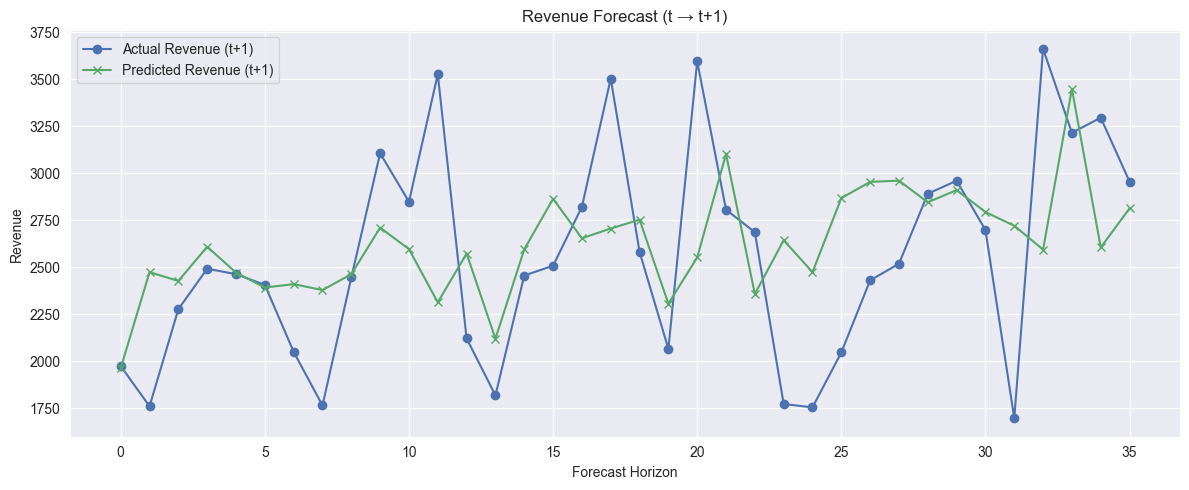

In [210]:
plt.figure(figsize=(12,5))

# Select two colors from the palette
actual_color = palette[0]
pred_color = palette[2]

# Shift actual revenue to match t+1 horizon
actual = y_test_arx.reset_index(drop=True)
predicted = pd.Series(y_pred_arx)

plt.plot(actual, label="Actual Revenue (t+1)", marker="o", color=actual_color)
plt.plot(predicted, label="Predicted Revenue (t+1)", marker="x", color=pred_color)

plt.title("Revenue Forecast (t → t+1)")
plt.xlabel("Forecast Horizon")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

#### 5.3.4 Residual Analysis (Normality, Autocorrelation, Heteroscedasticity)

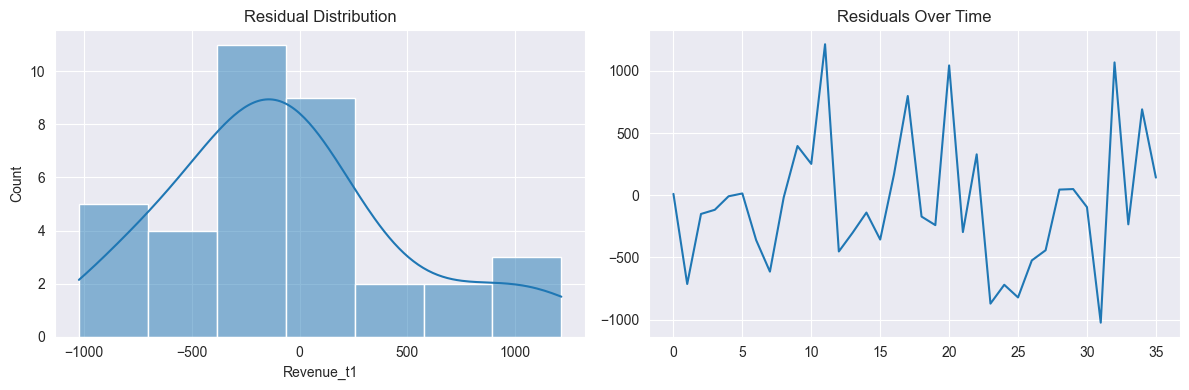

In [211]:
residuals = y_test_arx - y_pred_arx
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

plt.subplot(1,2,2)
plt.plot(residuals.values)
plt.title("Residuals Over Time")

plt.tight_layout()
plt.show()


In [212]:
residuals.describe()

count      36.000000
mean      -68.011956
std       540.751535
min     -1024.299373
25%      -380.786497
50%      -128.077726
75%       148.270721
max      1213.925185
Name: Revenue_t1, dtype: float64

#### 5.3.5 QQ-Plot

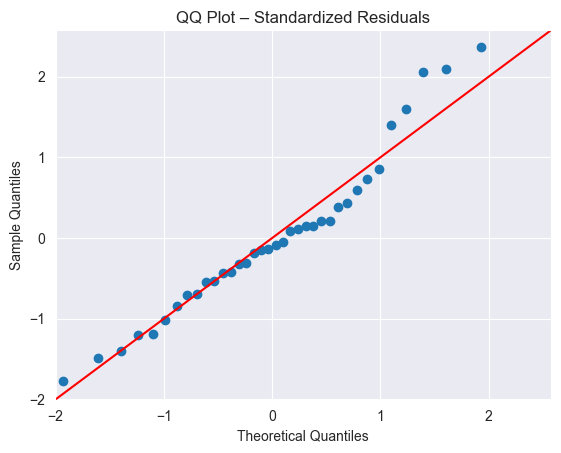

In [213]:
std_resid = (residuals - residuals.mean()) / residuals.std()
sm.qqplot(std_resid, line="45")
plt.title("QQ Plot – Standardized Residuals")
plt.show()


#### 5.3.6 Jarque–Bera Test for Residual Normality

In [214]:
jb, p, skew, kurt = jarque_bera(residuals)
jb, p, skew, kurt

(2.3907953494749536,
 0.30258360039904597,
 0.6295590298694204,
 3.0921155684785835)

In this model, the Jarque–Bera test yields a p-value greater than 0.05, so the null hypothesis of normality cannot be rejected. This indicates **no statistical evidence of non-normality in the residuals**. Visual inspection of the QQ-plot supports this result, as the standardized residuals align reasonably well with the theoretical normal distribution. Mild deviations in the tails are expected given the limited sample size (n = 36) and do not materially undermine the normality assumption of the OLS model.

#### 5.3.7 Durbin–Watson Test for Residual Autocorrelation

In [215]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
dw

1.9968334846464213

The Durbin–Watson statistic evaluates the presence of first-order autocorrelation in the regression residuals.

- **Null Hypothesis (H₀):** No first-order autocorrelation.
- **Alternative Hypothesis (H₁):** Presence of first-order autocorrelation.

The Durbin–Watson statistic is close to the theoretical benchmark of 2, indicating no evidence of first-order residual autocorrelation. This result suggests that the inclusion of a second autoregressive term successfully captures the dominant temporal dependence in revenue dynamics, addressing the residual autocorrelation observed in lower-order specifications.

#### 5.3.8 Breusch–Pagan Test for Heteroscedasticity

In [216]:
from statsmodels.stats.diagnostic import het_breuschpagan
y_train_pred = model.predict(X_train)
residuals_train = y_train_arx - y_train_pred

bp_test = het_breuschpagan(residuals_train, X_train_sm)
bp_test

(20.698210528943022,
 0.07911613601612792,
 1.6800886952840979,
 0.07267519376350585)

The Breusch–Pagan test evaluates whether the regression residuals exhibit constant variance (homoskedasticity).

- **Null Hypothesis (H₀):** The residuals are homoskedastic (constant variance).
- **Alternative Hypothesis (H₁):** The residuals are heteroskedastic (non-constant variance).

TheBreusch–Pagan test yields F and LM p-values slightly above the 5% significance level, indicating that the null hypothesis of homoskedasticity cannot be rejected. However, the borderline nature of the results suggests mild variance instability, which should be interpreted with caution given the limited sample size.

#### 5.3.9 ARX Model — Predictive Regression (t → t+1), Volume-Driven (Level Specification) — Summary

This level-based ARX(2) model serves as a parsimonious **baseline**, fully consistent with the EDA findings of strong revenue persistence, non-stationarity in levels, pronounced seasonality, and severe price multicollinearity (hence prices are excluded). Forecast accuracy is **moderate** (MAPE/WAPE/RMSE), but visual inspection shows that the model systematically **smooths the series**, failing to capture sharp peaks and troughs. This behavior is expected given the dominance of lagged revenue terms and the absence of explicit seasonal structure.

Residual diagnostics reinforce a cautious interpretation. While there is no evidence of residual non-normality, the remaining limitations in capturing seasonal amplitude confirm that a simple level-based ARX specification is insufficient to fully represent revenue dynamics.

Overall, this model should be interpreted strictly as a **benchmark and diagnostic reference**, not as a final forecasting solution. Its limitations empirically validate the EDA conclusions and motivate the transition to transformed and seasonally enriched specifications, such as log-scale ARX models with Fourier or SARIMAX-type seasonal components.

### 5.4 ARX Model — Volume-Driven Predictive Regression in Log-Growth with Fourier Terms

This predictive ARX specification is directly informed by the findings of the Exploratory Data Analysis (Section 3). The EDA identified (i) strong temporal dependence in revenue, (ii) non-stationarity in levels, (iii) pronounced seasonality, and (iv) severe multicollinearity among price variables, alongside evidence that revenue dynamics are primarily volume-driven rather than price-driven in a forecasting context. This specification directly addresses the limitations observed in the level-based ARX model, particularly residual autocorrelation and the inability to capture seasonal amplitude.

To address these issues, the model is formulated in **log-differenced form**, ensuring stationarity and mitigating spurious regression risks associated with trending series. Log-differencing directly responds to the unit-root behavior detected in revenue, units, and marketing variables during the EDA, while also stabilizing variance and reducing scale effects.

Price variables are intentionally excluded from the predictive specification due to their extreme multicollinearity and limited incremental forecasting value once volume dynamics are accounted for. This restriction reflects the EDA finding that prices exhibit strong contemporaneous associations with revenue but weak out-of-sample predictive contribution.

The model adopts an **ARX structure in growth rates**, capturing short-term revenue momentum through an autoregressive term in log-differenced revenue, while incorporating volume and marketing shocks as exogenous drivers. Seasonal patterns identified in the EDA are explicitly modeled using deterministic **Fourier terms**, allowing the regression to capture smooth monthly seasonality without introducing additional non-stationarity or excessive parameterization.

The predictive specification is defined as:

$\Delta \log(\text{Revenue}_{t+1}) = \beta_0 + \beta_1 \cdot \Delta \log(\text{Revenue}_t) + \beta_2 \cdot \Delta \log(\text{Revenue}_{t-1}) + \sum_j \gamma_j \cdot \Delta \log(\text{Units}_{j,t}) + \delta \cdot \Delta \log(\text{Marketing}_t) + \phi_1 \cdot \sin\left(\frac{2\pi t}{12}\right) + \phi_2 \cdot \cos\left(\frac{2\pi t}{12}\right) + \varepsilon_t$

Where:

- $\Delta \log(\text{Revenue}_{t+1})$ is the one-period-ahead revenue growth rate (forecast target)
- $\Delta \log(\text{Revenue}_t)$ captures short-term revenue persistence
- $\Delta \log(\text{Revenue}_{t-1})$ captures medium-term seasonal persistence consistent with quarterly dynamics
- $\Delta \log(\text{Units}_{j,t})$ represent contemporaneous volume shocks across segments
- $\Delta \log(\text{Marketing}_t)$ captures short-term marketing-driven demand effects
- Fourier sine and cosine terms model deterministic monthly seasonality
- $\varepsilon_t$ is the innovation term

This specification corresponds to a **volume-driven ARX model in stationary growth rates**, designed for short-horizon forecasting and diagnostic analysis. The model intentionally prioritizes temporal consistency, parsimony, and out-of-sample robustness over coefficient-level statistical significance or structural interpretability.


In [217]:
arxl = df.copy()
arxl = arxl.sort_values("datekey").reset_index(drop=True)

# Identify unit columns (volume drivers)
unit_cols = [c for c in arxl.columns if c.startswith("units_")]
# Units: log + Δlog
dlog_units_cols = []
for c in unit_cols:
    log_c = f"log_{c}"
    dlog_c = f"dlog_{c}"
    arxl[log_c] = np.log(arxl[c])
    arxl[dlog_c] = arxl[log_c].diff()
    dlog_units_cols.append(dlog_c)   

# Revenue: log + Δlog
arxl["log_rev"] = np.log(arxl["Revenue"])
arxl["dlog_rev"] = arxl["log_rev"].diff()

# Revenue lagged: log + Δlog
arxl["dlog_rev_lag1"] = arxl["dlog_rev"].shift(1)

# Marketing: log + Δlog
arxl["log_Marketing"]  = np.log(arxl["Marketing"])
arxl["dlog_Marketing"] = arxl["log_Marketing"].diff()

# Target: Δlog(Revenue_{t+1})
arxl["y_dlog_rev_t1"] = arxl["dlog_rev"].shift(-1)

# Fourier seasonality (monthly: period=12)
t = np.arange(len(arxl))
arxl["fourier_sin_1"] = np.sin(2 * np.pi * t / 12)
arxl["fourier_cos_1"] = np.cos(2 * np.pi * t / 12)

# Final feature set (volume-driven, parsimonious)
features = ["dlog_rev", "dlog_rev_lag1", "dlog_Marketing", "fourier_sin_1", "fourier_cos_1"] + dlog_units_cols

# Drop rows with NaNs created by diff/shift
arxl_model_df = arxl[["y_dlog_rev_t1"] + features].dropna()
print(arxl_model_df.columns)

# Time-series split (no shuffle) — based on ARX dataset
n_arxl = len(arxl_model_df)
train_size = int(n_arxl * 0.8)

train = arxl_model_df.iloc[:train_size]
test  = arxl_model_df.iloc[train_size:]

# Target
y_train_arxl = train["y_dlog_rev_t1"]
y_test_arxl  = test["y_dlog_rev_t1"]

# Features
X_trainl = train.drop(columns=["y_dlog_rev_t1"])
X_testl  = test.drop(columns=["y_dlog_rev_t1"])

print("X_train:", X_train.shape)
print("y_train:", y_train_arxl.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test_arxl.shape)

Index(['y_dlog_rev_t1', 'dlog_rev', 'dlog_rev_lag1', 'dlog_Marketing',
       'fourier_sin_1', 'fourier_cos_1', 'dlog_units_D_A', 'dlog_units_D_E',
       'dlog_units_D_I', 'dlog_units_O_A', 'dlog_units_O_E', 'dlog_units_O_I',
       'dlog_units_R_A', 'dlog_units_R_E', 'dlog_units_R_I'],
      dtype='object')
X_train: (142, 13)
y_train: (141,)
X_test : (36, 13)
y_test : (36,)


#### 5.4.1 Full Statistical Summary

In [218]:
model = LinearRegression()
model.fit(X_trainl, y_train_arxl)
y_pred_arxl = model.predict(X_testl)

# Add constant term
X_train_sml = sm.add_constant(X_trainl)
X_test_sml = sm.add_constant(X_testl)
# Fit model
model_sml = sm.OLS(y_train_arxl, X_train_sml).fit()
# Summary
model_sml.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          y_dlog_rev_t1   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     2.289
Date:                Wed, 25 Feb 2026   Prob (F-statistic):            0.00795
Time:                        12:40:45   Log-Likelihood:                -15.092
No. Observations:                 141   AIC:                             60.18
Df Residuals:                     126   BIC:                             104.4
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0145      0.026      0.561      0.576      -0.037       0.066
dlog_rev           2.9707      4.761      0.624      0.534      -6.452      12.393
dlog_rev_lag1     -0.3689      0.088     -4.194      0.000      -0.543      -0.195
dlog_Marketing    -0.0797      0.835     -0.095      0.924      -1.731       1.572
fourier_sin_1      0.0435      0.034      1.283      0.202      -0.024       0.111
fourier_cos_1     -0.0267      0.038     -0.700      0.485      -0.102       0.049
dlog_units_D_A    -2.0438      4.486     -0.456      0.649     -10.922       6.834
dlog_units_D_E     0.5540      0.533      1.040      0.300      -0.500       1.608
dlog_units_D_I    -0.1001      4.550     -0.022      0.982      -9.104       8.904
dlog_units_O_A     0.6294      1.567      0.402      0.689      -2.472       3.731
dlog_units_O_E    -1.8686      1.964     -0.952      0.343      -5.754       2.017
dlog_units_O_I     0.1286      0.431      0.298      0.766      -0.725       0.982
dlog_units_R_A    -0.7624      2.619     -0.291      0.771      -5.945       4.420
dlog_units_R_E     0.1794      2.848      0.063      0.950      -5.456       5.815
dlog_units_R_I    -0.0133      1.274     -0.010      0.992      -2.534       2.508
==============================================================================
Omnibus:                        4.353   Durbin-Watson:                   2.243
Prob(Omnibus):                  0.113   Jarque-Bera (JB):                4.179
Skew:                          -0.422   Prob(JB):                        0.124
Kurtosis:                       3.002   Cond. No.                         291.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [219]:
### Significant Coefficients
pvals = model_sml.pvalues
params = model_sml.params
# Filter variables with p-value < 0.05
significant_vars = pvals[pvals < 0.05].index
# Show coefficients only for significant variables
significant_coefs = params[significant_vars]
significant_coefs

dlog_rev_lag1   -0.368909
dtype: float64

In [220]:
idx = test.index

date_t  = arxl.loc[idx, "datekey"].values
date_t1 = arxl.loc[idx + 1, "datekey"].values

print("Exemplos t:", date_t[:5])
print("Exemplos t+1:", date_t1[:5])


Exemplos t: [202112 202201 202202 202203 202204]
Exemplos t+1: [202201 202202 202203 202204 202205]


#### 5.4.2 Log-to-Level Transformation and Model Evaluation

In [221]:
log_rev_t = arxl.loc[test.index, "log_rev"].values
log_rev_t1_pred = log_rev_t + y_pred_arxl
rev_t1_pred = np.exp(log_rev_t1_pred)
rev_t1_true = arxl.loc[test.index + 1, "Revenue"].values

mape_arx = mean_absolute_percentage_error(rev_t1_true, rev_t1_pred)
rmse_arx  = np.sqrt(mean_squared_error(rev_t1_true, rev_t1_pred))
wape_arx = np.sum(np.abs(rev_t1_true - rev_t1_pred)) / np.sum(np.abs(rev_t1_true))

print("MAPE_ARX:", round(mape_arx * 100, 2), "%")
print("WAPE_ARX:", round(wape_arx * 100, 2), "%")
print("RMSE_ARX:", round(rmse_arx, 2))

MAPE_ARX: 23.45 %
WAPE_ARX: 21.82 %
RMSE_ARX: 688.29


#### 5.4.3 Plot Revenue vs Predicted

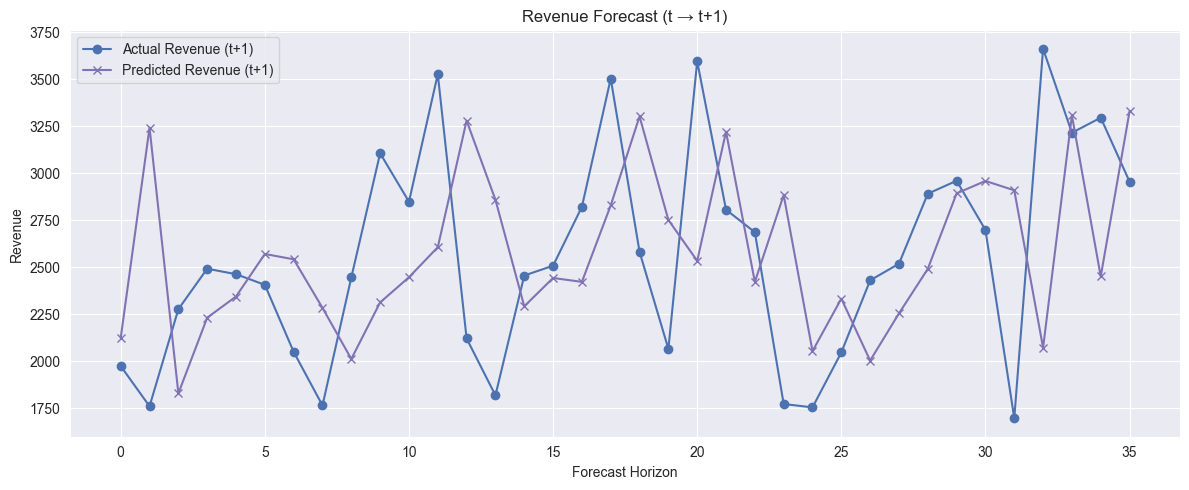

In [222]:
plt.figure(figsize=(12,5))

# Select two colors from the palette
actual_color = palette[0]
pred_color = palette[4]

# Shift actual revenue to match t+1 horizon
actual = rev_t1_true
predicted = pd.Series(rev_t1_pred)

plt.plot(actual, label="Actual Revenue (t+1)", marker="o", color=actual_color)
plt.plot(predicted, label="Predicted Revenue (t+1)", marker="x", color=pred_color)

plt.title("Revenue Forecast (t → t+1)")
plt.xlabel("Forecast Horizon")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

#### 5.4.4 ARX Predictive Regression Model (t → t+1) — Volume-Driven: Summary

The log-growth ARX model with Fourier terms represents a theoretically consistent extension of the level-based ARX, directly addressing the EDA findings of non-stationarity and pronounced seasonality. However, **out-of-sample forecasting performance remains weak**. The loss metrics (MAPE, WAPE, and RMSE) are high relative to the scale and volatility of the revenue series, indicating limited one-step-ahead predictive accuracy after back-transformation to levels.

Visual inspection of the forecasts reinforces this conclusion. While the model is able to **replicate the general cyclical structure and identify peaks and troughs**, these movements occur with a **systematic delay**, meaning the model reacts to realized changes rather than anticipating them. As a result, sharp turning points are captured only after they occur, leading to large forecast errors at critical moments.

Overall, this ARX log-growth specification should be interpreted strictly as a **diagnostic and benchmarking model**. It confirms the EDA insight that short-term revenue dynamics are dominated by persistence and seasonality, and that linear ARX models—despite proper transformation and seasonal controls—are insufficient for accurate short-horizon forecasting. These results motivate the transition to more flexible stochastic time-series models in subsequent sections.

### 5.5 Autoregressive (AR) Models on Transformed Revenue Series

The Exploratory Data Analysis (Section 3) revealed strong autocorrelation, non-stationarity, and pronounced revenue persistence. In addition, all previous predictive specifications consistently identified **Revenue Lag 1** as the dominant driver of short-horizon forecasts, while exogenous variables added limited incremental predictive power.

Motivated by these findings, this section focuses exclusively on **pure autoregressive (AR) models**, removing all exogenous drivers and modeling only the internal dynamics of Revenue. The objective is to assess whether alternative transformations of the revenue series reduce persistence, improve stationarity, and enhance short-term forecastability.

We estimate AR(1) specifications for four transformed versions of Revenue, each addressing a distinct structural issue identified in the EDA:

- **Revenue Difference (First Difference):**  $Revenue_{diff,t} = \alpha + \beta \cdot Revenue_{diff,t-1} + \varepsilon_t$

- **Revenue Percentage Change:**  $Revenue_{pct\_change,t} = \alpha + \beta \cdot Revenue_{pct\_change,t-1} + \varepsilon_t$

- **Revenue YoY Difference:**  $Revenue_{yoy\_diff,t} = \alpha + \beta \cdot Revenue_{yoy\_diff,t-1} + \varepsilon_t$

- **Detrended Revenue:**  $Revenue_{detrended,t} = \alpha + \beta \cdot Revenue_{detrended,t-1} + \varepsilon_t$

Each transformation is designed to address a specific structural issue identified in the EDA:

| Transformation       | EDA Issue Addressed                         |
|----------------------|---------------------------------------------|
| First Difference     | Non-stationarity (unit root)                |
| Percent Change       | Scale effects and heteroskedasticity        |
| YoY Difference       | Trend and seasonal components               |
| Detrended Revenue    | Long-term structural trend                  |


Unlike the ARX models, these specifications rely solely on lagged values of the transformed series and do not incorporate economic drivers. As such, they are intended to evaluate whether transforming Revenue weakens structural persistence and yields more statistically tractable dynamics, rather than to provide economic interpretation or driver-based insights.



In [223]:
lag = df.copy()
lag = lag.dropna()
lag = lag.drop(columns = ['datekey', 'Trend','Revenue_t1', 'Marketing', 'price_D_A', 'price_D_E', 'price_D_I', 'price_O_A', 'price_O_E', 'price_O_I', 'price_R_A', 'price_R_E', 'price_R_I',
                           'units_D_A', 'units_D_E', 'units_D_I', 'units_O_A', 'units_O_E', 'units_O_I', 'units_R_A', 'units_R_E', 'units_R_I'])
lag.shape, lag.columns

((167, 7),
 Index(['Revenue', 'Revenue_lag1', 'Revenue_lag12', 'Revenue_diff',
        'Revenue_yoy_diff', 'Revenue_pct_change', 'Revenue_detrended'],
       dtype='object'))

#### 5.5.1 Building the AR(1) Forecasting Function

In [224]:
def run_model_full(series_name):
    # Build lag column
    lag[series_name + "_lag1"] = lag[series_name].shift(1)

    # Select target and lag1
    data = lag[[series_name, series_name + "_lag1"]].dropna()

    # Train-test split 80/20
    n = len(data)
    train_size = int(n * 0.8)
    train = data.iloc[:train_size]
    test  = data.iloc[train_size:]

    # X and y
    X_train = train[[series_name + "_lag1"]]
    y_train = train[series_name]

    X_test = test[[series_name + "_lag1"]]
    y_test = test[series_name]

    # Fit model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    return y_pred

#### 5.5.2 AR(1) Forecasts Across All Revenue Transformations

In [225]:
transformations = [
    "Revenue_diff",
    "Revenue_pct_change",
    "Revenue_yoy_diff",
    "Revenue_detrended"
]

results_dict = {}    # dictionary where each key will become a column

for series in transformations:
    y_pred = run_model_full(series)   # the function already returns only y_pred
    
    # Ensure the prediction is stored properly as a column
    results_dict["AR1_" + series] = y_pred

# Create a dataframe where columns = AR(1) forecasts for each transformation
results_df = pd.DataFrame(results_dict)

print(results_df.shape)
results_df.head()


(34, 4)


,AR1_Revenue_diff,AR1_Revenue_pct_change,AR1_Revenue_yoy_diff,AR1_Revenue_detrended
0,1.071309,0.061525,23.726134,-94.106445
1,53.493066,0.089073,110.374209,-139.146782
2,-100.119714,0.001631,98.246961,-35.681507
3,-36.778335,0.044913,57.887718,6.548301
4,14.627790,0.068035,32.866820,-0.918915


#### 5.5.3 Reconstructing Revenue from Transformed Forecasts

In [226]:
# 1. Get Trend_hat directly from the regression fit
trend_model = sm.OLS(df["Revenue"], sm.add_constant(df["Trend"])).fit()
lag["Trend_hat"] = trend_model.fittedvalues

# 2. Align test rows
test_len = len(results_df)
lag_test = lag.tail(test_len).copy()

# 3. Reverse the transformations

# Difference
results_df["Revenue_from_diff"] = (
    lag_test["Revenue_lag1"].values + results_df["AR1_Revenue_diff"].values
)

# Percent change
results_df["Revenue_from_pct"] = (
    lag_test["Revenue_lag1"].values * (1 + results_df["AR1_Revenue_pct_change"].values)
)

# YoY difference
results_df["Revenue_from_yoy"] = (
    lag_test["Revenue_lag12"].values + results_df["AR1_Revenue_yoy_diff"].values
)

# Detrended
# Revenue_real = Trend_hat + Residual -> Residual = Revenue_real − Trend_hat -> Revenue_real = Trend_hat + Revenue_detrended
results_df["Revenue_from_detrended"] = (
    lag_test["Trend_hat"].values + results_df["AR1_Revenue_detrended"].values
)


#### 5.5.4 Consolidating Actual vs Reconstructed Revenue

In [227]:
lag_reg = results_df[[ 'Revenue_from_diff', 'Revenue_from_pct', 'Revenue_from_yoy', 'Revenue_from_detrended']].copy()
lag_reg["Revenue"] = lag["Revenue"].tail(len(lag_reg)).reset_index(drop=True)
order = ["Revenue", 'Revenue_from_diff', 'Revenue_from_pct', 'Revenue_from_yoy', 'Revenue_from_detrended' ]
lag_reg[order].tail()

,Revenue,Revenue_from_diff,Revenue_from_pct,Revenue_from_yoy,Revenue_from_detrended
29,2697.61,2953.329220,3137.782445,2735.634101,2643.818147
30,1695.65,2761.154249,2926.178379,2143.824649,2596.693587
31,3661.04,1914.846704,1943.685956,3729.664123,2399.091552
32,3214.65,3256.274810,2977.885199,2890.137913,2804.706539
33,3294.93,3317.023778,3510.441012,2730.971995,2720.043417


In [228]:
### Actual vs Reconstructed Revenue Alignment Check
pd.concat([
    lag_test["Revenue"].reset_index(drop=True),
    lag_reg["Revenue"]
], axis=1).head()


,Revenue,Revenue
0,1759.38,1759.38
1,2275.98,2275.98
2,2491.35,2491.35
3,2462.25,2462.25
4,2405.49,2405.49


#### 5.5.5 Evaluating AR(1) Models (MAPE, WAPE and RMSE)

In [229]:
# DataFrame: lag_reg (contains Revenue and the 4 reconstructed forecasts)

metrics = {}

for col in ["Revenue_from_diff", "Revenue_from_pct", 
            "Revenue_from_yoy", "Revenue_from_detrended"]:
    
    y_true = lag_reg["Revenue"].values
    y_pred = lag_reg[col].values
    
    # RMSE
    rmse = round(np.sqrt(np.mean((y_true - y_pred)**2)),2)
    
    # MAPE (avoid division by zero)
    mape = round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100,2)

    # WAPE
    wape =round(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))* 100,2)
    
    metrics[col] = {"MAPE (%)": mape, "WAPE (%)": wape, "RMSE": rmse}

metrics_df = pd.DataFrame(metrics).T
metrics_df


,MAPE (%),WAPE (%),RMSE
Revenue_from_diff,20.37,19.57,644.77
Revenue_from_pct,21.48,20.19,663.46
Revenue_from_yoy,16.34,15.73,581.17
Revenue_from_detrended,16.60,16.10,539.17


#### 5.5.6 Plotting Actual vs Predicted Revenue

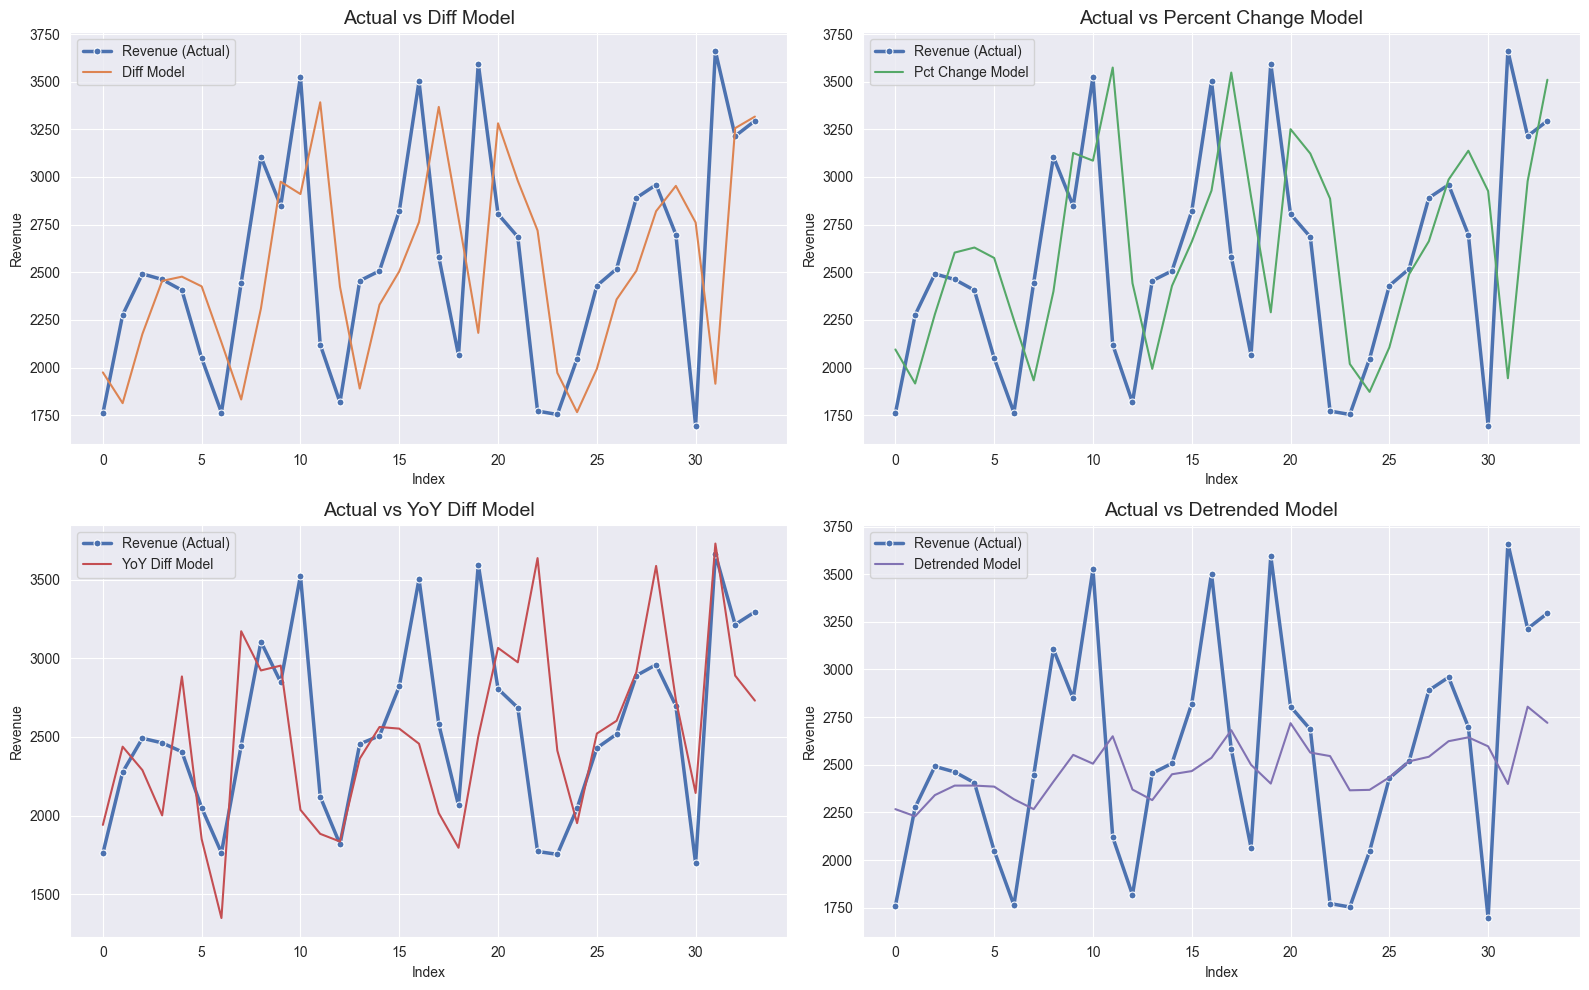

In [230]:
plt.figure(figsize=(16, 10))

# Helper: real revenue line params
rev_style = dict(
    color=palette[0],     # blue
    marker="o",
    linewidth=2.5,
    markersize=5
)

# 1. Diff Model
plt.subplot(2, 2, 1)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue", label="Revenue (Actual)", **rev_style)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue_from_diff", 
             label="Diff Model", color=palette[1])
plt.title("Actual vs Diff Model", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 2. Percent Change Model
plt.subplot(2, 2, 2)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue", label="Revenue (Actual)", **rev_style)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue_from_pct",
             label="Pct Change Model", color=palette[2])
plt.title("Actual vs Percent Change Model", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 3. YoY Diff Model
plt.subplot(2, 2, 3)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue", label="Revenue (Actual)", **rev_style)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue_from_yoy",
             label="YoY Diff Model", color=palette[3])
plt.title("Actual vs YoY Diff Model", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 4. Detrended Model
plt.subplot(2, 2, 4)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue", label="Revenue (Actual)", **rev_style)
sns.lineplot(data=lag_reg, x=lag_reg.index, y="Revenue_from_detrended",
             label="Detrended Model", color=palette[4])
plt.title("Actual vs Detrended Model", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()


### 5.5.7 — Summary: Autoregressive (AR) Models on Transformed Revenue Series

This section evaluated pure AR(1) models applied to multiple transformations of the Revenue series— **first differences, percentage change, year-over-year differences, and detrended revenue** —with the objective of weakening structural persistence and assessing whether transformed representations yield improved short-horizon forecastability relative to level-based models.

From a quantitative perspective, the **YoY-differenced** and **detrended** specifications achieve the lowest forecast errors, respectively. These results represent a modest improvement over the AR(1) models based on first differences and percentage changes, which exhibit higher error levels and weaker stability.

However, visual diagnostics reveal that these apparent gains in loss functions are primarily driven by **forecast smoothing rather than improved dynamic tracking**. The detrended AR model generates overly smooth trajectories that follow the long-term level of revenue but systematically fail to capture short-term volatility and sharp turning points. Similarly, the YoY-differenced model captures medium-term movements more effectively than other transformations, yet still displays delayed reactions around local peaks and troughs.

In contrast, the **first-difference** and **percentage-change** models exhibit pronounced phase lag and excess noise, responding to revenue movements only after they materialize and producing erratic short-term forecasts. As a result, these specifications show limited point-by-point accuracy despite their ability to reduce persistence and enforce stationarity.

Overall, while transformed AR(1) models can reduce average forecast errors by attenuating trend and persistence, these improvements come at the cost of **dynamic realism and responsiveness**. When evaluated jointly using **error metrics and visual inspection**, none of the transformed AR specifications provide a clear practical advantage over the ARX framework. Consequently, pure AR models on transformed revenue are best interpreted as **diagnostic benchmarks**, confirming the dominance of persistence and structural components, rather than as superior standalone forecasting solutions.


### 5.6 — Linear Regression Frameworks: Consolidated Summary

This section evaluates a set of **linear regression–based frameworks** as an intermediate analytical layer within the overall forecasting pipeline. All specifications are treated explicitly as **diagnostic and benchmarking tools**, designed to test structural hypotheses derived from the EDA rather than to deliver a definitive forecasting model.

The analysis spans multiple linear formulations, including:
- **Disaggregated predictive regressions by channel and product**, assessing whether heterogeneity improves short-horizon accuracy;
- **Level-based ARX models (t → t+1)**, emphasizing persistence and volume-driven dynamics;
- **Log-growth ARX models with Fourier terms**, addressing non-stationarity and deterministic seasonality;
- **Pure autoregressive AR(1) models** applied to several transformed representations of the Revenue series.

Across all linear specifications, results are highly consistent. **Revenue persistence dominates short-term dynamics**, with autoregressive terms explaining the majority of one-period-ahead variation. Exogenous drivers—particularly unit volumes—provide limited and unstable incremental predictive power once autoregressive structure is included, while prices are systematically excluded due to severe multicollinearity and negligible marginal contribution.

While certain transformed AR specifications (notably detrended and year-over-year differences) achieve lower average forecast errors, **visual diagnostics reveal that these gains largely reflect smoothing rather than genuine improvements in dynamic tracking**. Level-based ARX models smooth peaks and troughs, log-growth ARX models with seasonal controls exhibit systematic reaction delays, and pure AR models trade responsiveness for apparent error reduction.

Taken together, **no linear regression framework emerges as a robust standalone forecasting solution**. Each specification highlights a different structural limitation—whether persistence dominance, phase lag, or loss of dynamic realism—reinforcing the conclusion that linear models are best interpreted as **analytical benchmarks rather than optimal predictors**.

**Bridge to Time-Series Models (ARIMA Family).**  
The collective findings from the linear regression analysis directly confirm the EDA conclusions: revenue dynamics are governed by persistence, seasonality, and stochastic shocks that exceed the expressive capacity of linear ARX formulations. These limitations motivate the transition, in the following sections, to **ARIMA-family models**, where differencing, stochastic trends, and explicit seasonal structures are treated natively within a unified time-series framework.

## 6. ARIMA Family Models — Time-Series Forecasting

### 6.1 ARIMA Model — Conceptual Overview

The ARIMA family of models combines Autoregression (AR), Moving Average (MA), and Differencing (I) to model both the temporal dependence and the stochastic structure of a time series.

#### Autoregressive Component (AR)

The Autoregressive (AR) model describes a time series using its own past values.

An AR model of order p can be written as:

y_t = c + φ1 * y_(t-1) + φ2 * y_(t-2) + ... + φp * y_(t-p) + ε_t

Where:

- y_t: value of the series at time t  
- φ_i: autoregressive coefficients  
- c: constant (drift term)  
- ε_t: white-noise error term  

Interpretation:  
The AR component captures persistence or momentum in the series — if past values are high, current values tend to remain high.

Identification:  
- The PACF exhibits a sharp cutoff at lag p  
- The ACF decays gradually  

#### Moving Average Component (MA)

The Moving Average (MA) model represents the series as a function of past shocks (errors).

An MA model of order q can be written as:

y_t = μ + ε_t + θ1 * ε_(t-1) + θ2 * ε_(t-2) + ... + θq * ε_(t-q)

Where:

- θ_j: moving-average coefficients  
- ε_(t-j): past error terms (unexpected shocks)  

Interpretation:  
The MA component captures temporary shock effects — unexpected past events continue to influence the present.

Identification:  
- The ACF exhibits a sharp cutoff at lag q  
- The PACF decays gradually  

#### Integration Component (I) — Differencing

Most real-world time series are non-stationary due to trends, seasonality, or changing variance.  
The Integration component makes the series stationary through differencing.

A first difference is defined as:

Δy_t = y_t − y_(t-1)

After differencing d times, the transformed series is obtained.

Interpretation:  
Differencing removes trends and unit-root behavior, enabling the use of AR and MA components.

#### Full ARIMA Model

y_t = c + φ1 * y_(t-1) + φ2 * y_(t-2) + ... + φp * y_(t-p) + ε_t + θ1 * ε_(t-1) + θ2 * ε_(t-2) + ... + θq * ε_(t-q)

The ARIMA(p, d, q) model combines all three components:

- p: autoregressive order  
- d: number of differences  
- q: moving average order  

Conceptually, the model applies differencing to achieve stationarity and then models the resulting series using AR and MA dynamics.

#### ARIMA Modeling Framework — Extension of the Empirical Revenue Analysis

Based on the exploratory analysis conducted in previous sections, several key characteristics of the Revenue time series are already well established:

- The series exhibits **strong temporal persistence**, with Revenue Lag 1 consistently identified as the dominant explanatory variable.
- The level series is **non-stationary**, as confirmed by the Augmented Dickey–Fuller (ADF) test, indicating the presence of a **unit root**.
- Visual inspection and autocorrelation analysis suggest that the dynamics of Revenue are largely consistent with a **low-order autoregressive process**, potentially AR(1), combined with stochastic shocks.
- Transformations such as differencing and detrending improve stationarity but introduce trade-offs in dynamic tracking and interpretability.

Given these findings, ARIMA modeling is introduced as a **natural extension of the linear autoregressive framework**, allowing the joint modeling of:
- Autoregressive persistence (AR),
- Stochastic shocks (MA),
- And non-stationarity via differencing (I).

To support formal model identification, an **automatic ARIMA selection procedure (`auto_arima`)** is applied as a **robustness check**, rather than as a substitute for economic reasoning. The algorithm evaluates multiple ARIMA specifications by combining **unit-root tests** and **information criteria (AIC)**, providing a data-driven benchmark for the selection of parameters $( p )$, $( d )$, and $( q )$.

The automatically suggested specification is then compared against **manually specified, parsimonious models**—in particular low-order ARIMA models consistent with the observed AR(1)-type persistence—to ensure **interpretability, stability, and forecasting realism**.

### 6.2 Auto_ARIMA

To support model identification, an automatic ARIMA selection procedure (auto_arima) was applied as a robustness check. The algorithm evaluates multiple ARIMA specifications by combining unit-root tests and information criteria (AIC), providing a data-driven benchmark for p, d, and q selection. The suggested specification was then compared against manually specified parsimonious models to ensure interpretability and forecasting stability.


In [231]:
from pmdarima import auto_arima

ar = df[["Revenue"]].copy()

# Auto ARIMA selection
auto_model = auto_arima(
    ar,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=None,              # let the model test for integration (ADF/KPSS)
    seasonal=False,      # no SARIMA at this stage
    test="adf",          # unit root test
    information_criterion="aic",
    trace=True,          # show tested models
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3253.852, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2786.468, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=3074.598, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2779.650, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2764.651, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=2713.891, Time=0.19 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2723.122, Time=0.15 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=2709.778, Time=0.17 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2719.969, Time=0.15 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.25 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=2726.317, Time=0.16 sec

Best model:  ARIMA(3,0,2)(0,0,0)[0]          
Total fit time: 1.375 seconds
                               SARIMAX Results                                
Dep. Variable:     

#### 6.3 ARIMA Models

| Model        | Description                                                |
| ------------ | ---------------------------------------------------------- |
| ARIMA(1,1,0) | Structured random walk                                     |
| ARIMA(1,1,1) | Persistence with transitory shocks                         |
| ARIMA(3,0,2) | Best auto-ARIMA model (high complexity / overfitting risk) |


In [232]:
from statsmodels.tsa.arima.model import ARIMA

model_110 = ARIMA(ar, order=(1,1,0))
res_110 = model_110.fit()

print(res_110.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  180
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1378.747
Date:                Wed, 25 Feb 2026   AIC                           2761.494
Time:                        12:40:48   BIC                           2767.869
Sample:                             0   HQIC                          2764.079
                                - 180                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2337      0.074     -3.155      0.002      -0.379      -0.088
sigma2      2.884e+05   2.99e+04      9.635      0.000     2.3e+05    3.47e+05
Ljung-Box (L1) (Q):                   1.01   Jarque-

In [233]:
model_111 = ARIMA(ar, order=(1,1,1))
res_111 = model_111.fit()

print(res_111.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  180
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1348.743
Date:                Wed, 25 Feb 2026   AIC                           2703.486
Time:                        12:40:48   BIC                           2713.048
Sample:                             0   HQIC                          2707.363
                                - 180                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2414      0.081      2.990      0.003       0.083       0.400
ma.L1         -0.9211      0.036    -25.902      0.000      -0.991      -0.851
sigma2      2.031e+05   2.19e+04      9.261      0.0

In [234]:
model_302 = ARIMA(ar, order=(3,0,2))
res_302 = model_302.fit()

print(res_302.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  180
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1347.898
Date:                Wed, 25 Feb 2026   AIC                           2709.795
Time:                        12:40:48   BIC                           2732.146
Sample:                             0   HQIC                          2718.858
                                - 180                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1937.5205    715.469      2.708      0.007     535.227    3339.814
ar.L1          1.8352      0.220      8.357      0.000       1.405       2.266
ar.L2         -1.2346      0.265     -4.661      0.0

#### 6.3.1 ARIMA Model Comparison — Summary

Three ARIMA specifications were evaluated to model the Revenue time series:

- **ARIMA(1,1,0)**  
  A parsimonious random-walk-type model with drift. While structurally coherent given the presence of a unit root, it exhibited weaker overall fit (higher AIC) and residual heteroskedasticity.

- **ARIMA(1,1,1)**  
  This model achieved the **lowest AIC** among the integrated specifications and showed **well-behaved residual autocorrelation** (Ljung–Box test). It provides a balanced representation of persistence and short-term shocks, making it the **preferred specification** for forecasting.

- **ARIMA(3,0,2)** *(Best auto-ARIMA)*  
  Although flexible and statistically rich, this model does not incorporate differencing despite evidence of non-stationarity. Residual normality is rejected, and model complexity increases the risk of overfitting.

**Overall conclusion:**  

Although the auto-ARIMA procedure identified an **ARIMA(3,0,2)** specification with marginally competitive AIC, this model ignores robust evidence of non-stationarity in the Revenue series. In addition, it exhibits higher parametric complexity, rejection of residual normality (Jarque-Bera), and convergence issues, all of which increase the risk of overfitting and reduce forecasting reliability.

In contrast, the **ARIMA(1,1,1)** model provides the most appropriate trade-off between structural validity, residual diagnostics, parsimony, and predictive stability. Its integrated structure is consistent with unit-root behavior, residual autocorrelation is well controlled, and inference remains statistically sound. Consequently, **ARIMA(1,1,1) is selected as the benchmark univariate forecasting model** within the FP&A framework.

#### Results — Diagnostic Statistics Interpretation

The SARIMAX output reports several diagnostic statistics used to evaluate model adequacy and residual behavior:

- **Log Likelihood**  
  Measures the overall goodness-of-fit of the model. Higher values indicate a better fit to the observed data, conditional on the model structure.

- **AIC (Akaike Information Criterion)**  
  Balances model fit and complexity. Lower AIC values indicate a preferable trade-off between explanatory power and parsimony and are commonly used for model comparison.

- **BIC (Bayesian Information Criterion)**  
  Similar to AIC but imposes a stronger penalty on model complexity. It favors more parsimonious models, particularly in larger samples.

- **HQIC (Hannan–Quinn Information Criterion)**  
  An intermediate criterion between AIC and BIC, providing an additional robustness check for model selection.

- **Ljung–Box Test (Q-statistic)**  
  Evaluates whether residuals are serially uncorrelated.  
  - **H₀:** Residuals exhibit no autocorrelation (white noise).  
  - **H₁:** Residuals are autocorrelated.  
  A high p-value indicates that the model adequately captures the temporal dependence structure.

- **Jarque–Bera Test (JB)**  
  Assesses whether residuals follow a normal distribution based on skewness and kurtosis.  
  - **H₀:** Residuals are normally distributed.  
  - **H₁:** Residuals deviate from normality.  
  A high p-value supports valid statistical inference.

- **Heteroskedasticity Test (H)**  
  Tests whether the variance of residuals is constant over time.  
  - **H₀:** Residuals are homoskedastic (constant variance).  
  - **H₁:** Residuals are heteroskedastic (time-varying variance).  
  Rejection of H₀ indicates variance instability, which is common in economic and financial time series.

- **Skewness**  
  Measures asymmetry in the residual distribution. Positive values indicate right-skewness, while negative values indicate left-skewness.

- **Kurtosis**  
  Measures tail thickness relative to a normal distribution. Values above 3 indicate heavy tails, while values below 3 indicate lighter tails.


#### 6.4 ARIMA(1,1,1)

In [235]:
# Train / Test split
train_size = int(len(ar) * 0.8)
y_train = ar.iloc[:train_size]
y_test  = ar.iloc[train_size:]

# Model
from statsmodels.tsa.arima.model import ARIMA
model_111 = ARIMA(y_train, order=(2,1,1))
res_111 = model_111.fit()

# Forecast
n_forecast = len(y_test)
y_forecast = res_111.forecast(steps=n_forecast)

# MAPE e RMSE
mape = mean_absolute_percentage_error(y_test, y_forecast) * 100
rmse = np.sqrt(mean_squared_error(y_test, y_forecast))

y_true = y_test.values.flatten()
y_pred = y_forecast.values.flatten()
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

print(f"MAPE (%): {mape:.2f}")
print(f"WAPE (%): {wape:.2f}")
print(f"RMSE: {rmse:.2f}")


MAPE (%): 19.64
WAPE (%): 21.02
RMSE: 663.09


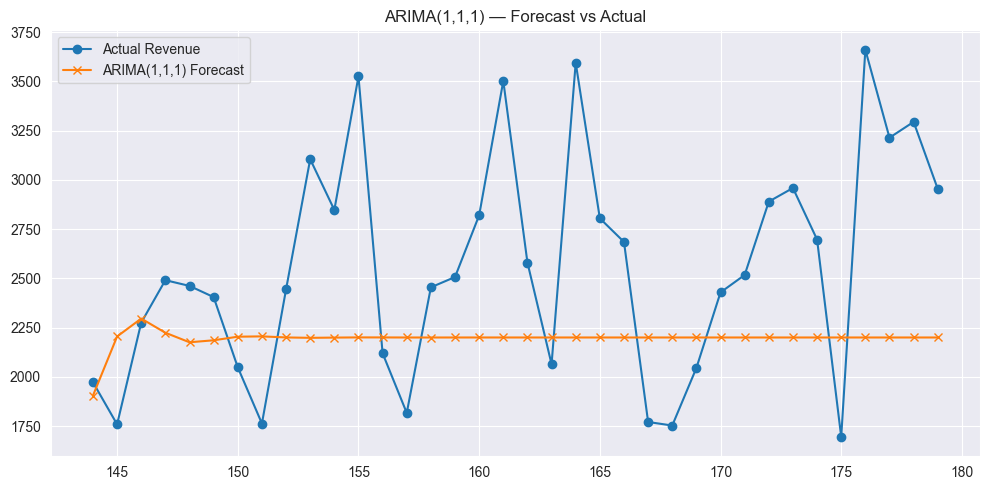

In [236]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual Revenue", marker="o")
plt.plot(y_test.index, y_forecast, label="ARIMA(1,1,1) Forecast", marker="x")
plt.title("ARIMA(1,1,1) — Forecast vs Actual")
plt.legend()
plt.tight_layout()
plt.show()


#### 6.4.1 ARIMA(1,1,1) - Summary

The near-linear out-of-sample forecast produced by the ARIMA(1,1,1) model is an expected theoretical outcome. As an integrated process, the model forecasts future changes rather than future shocks, and in the absence of new information, expected innovations converge to zero. Consequently, the level forecast stabilizes around its long-run conditional mean. This behavior confirms correct model specification but also highlights the limitations of non-seasonal ARIMA models when applied to strongly seasonal economic time series.

### 6.5 SARIMA

#### 6.5.1 Seasonal ARIMA (SARIMA) Model

The Seasonal ARIMA (SARIMA) model extends the standard ARIMA framework by explicitly incorporating **seasonal patterns** in the time series. While ARIMA captures short-term temporal dependence and stochastic shocks, SARIMA allows these dynamics to repeat systematically over fixed seasonal cycles.

A SARIMA model is denoted as:

SARIMA(p, d, q) × (P, D, Q)_s

Where:

- (p, d, q): non-seasonal ARIMA components
  - p: non-seasonal autoregressive order
  - d: non-seasonal differencing order
  - q: non-seasonal moving average order

- (P, D, Q): seasonal components
  - P: seasonal autoregressive order
  - D: seasonal differencing order
  - Q: seasonal moving average order

- s: length of the seasonal cycle (e.g., s = 12 for monthly data with annual seasonality)

The SARIMA model jointly captures:
- Short-run dynamics through AR and MA terms,
- Long-run non-stationarity via differencing,
- Recurrent seasonal behavior through seasonal AR, MA, and differencing operators.

By modeling both regular and seasonal dependence, SARIMA provides a flexible and parsimonious framework for time series exhibiting periodic structures such as monthly, quarterly, or weekly patterns.


#### 6.5.2 SARIMA(1,1,1)(1,1,1,12)

In [237]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12))  
res_sarima = model_sarima.fit()

y_forecast_sarima = res_sarima.forecast(steps=len(y_test))

mape_sarima = mean_absolute_percentage_error(y_test, y_forecast_sarima) * 100
rmse_sarima = np.sqrt(mean_squared_error(y_test, y_forecast_sarima))

y_true = y_test.values.flatten()
y_pred = y_forecast_sarima.values.flatten()
wape_sarima = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

print(f"SARIMA MAPE (%): {mape_sarima:.2f}")
print(f"SARIMA WAPE (%): {wape_sarima:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")


SARIMA MAPE (%): 11.45
SARIMA WAPE (%): 12.27
SARIMA RMSE: 418.27


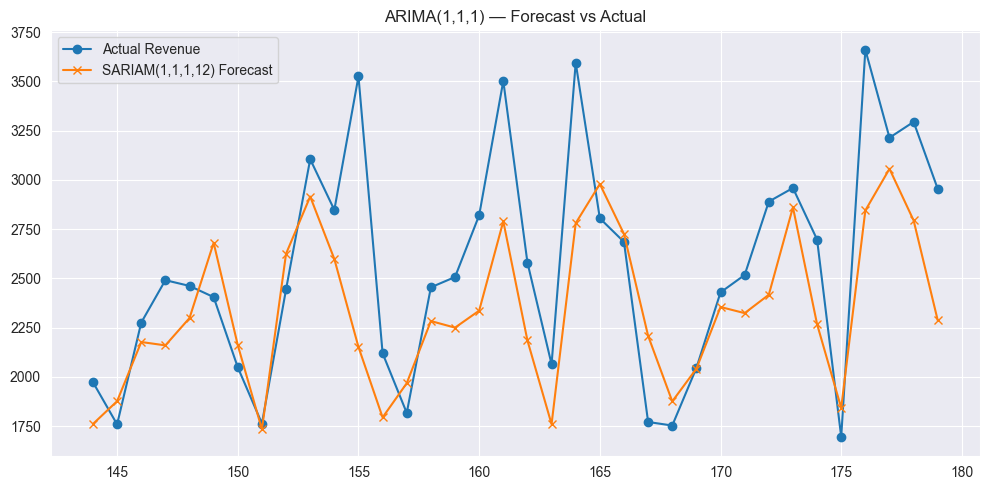

In [238]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual Revenue", marker="o")
plt.plot(y_test.index, y_forecast_sarima, label="SARIAM(1,1,1,12) Forecast", marker="x")
plt.title("ARIMA(1,1,1) — Forecast vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

#### 6.5.3 SARIMAX exogenous variables (Marketing and Trend)

In [239]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_vars = ["Marketing", "Trend"]
exog = df[exog_vars]

train_size = int(len(ar) * 0.8)

y_train = ar.iloc[:train_size]
y_test  = ar.iloc[train_size:]

exog_train = exog.iloc[:train_size]
exog_test  = exog.iloc[train_size:]


from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res_sarimax = model_sarimax.fit()

y_forecast_sarimax = res_sarimax.forecast(
    steps=len(y_test),
    exog=exog_test
)

mape_sarimax = mean_absolute_percentage_error(y_test, y_forecast_sarimax) * 100
rmse_sarimax = np.sqrt(mean_squared_error(y_test, y_forecast_sarimax))

y_true = y_test.values.flatten()
y_pred = y_forecast_sarimax.values.flatten()
wape_sarimax = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

print(f"SARIMAX MAPE (%): {mape_sarimax:.2f}")
print(f"SARIMAX WAPE (%): {wape_sarimax:.2f}")
print(f"SARIMAX RMSE: {rmse_sarimax:.2f}")


SARIMAX MAPE (%): 11.46
SARIMAX WAPE (%): 12.31
SARIMAX RMSE: 420.63


#### 6.6 — ARIMA Family Models: Time-Series Forecasting — Summary

This section consolidates the evaluation of the **ARIMA-family models** tested in this module, including ARIMA, SARIMA, and SARIMAX specifications, with the objective of identifying a robust and operationally sound baseline for revenue forecasting.

Empirical results show that **SARIMA(1,1,1)(1,1,1,12)** and **SARIMAX(1,1,1)(1,1,1,12)** (with Marketing and Trend as exogenous variables) achieve **nearly identical out-of-sample forecasting performance**, as measured by MAPE WAPE and RMSE. The inclusion of exogenous regressors does not yield a material improvement in predictive accuracy.

These findings are fully consistent with earlier regression diagnostics in Module 4, which indicate that short-term revenue dynamics are dominated by **persistence, stochastic trend, and seasonality**, while variables such as Marketing and deterministic Trend provide limited incremental information and are subject to multicollinearity. Importantly, the integrated and seasonal components of the SARIMA model already capture these structural features endogenously.

Consequently, the SARIMAX specification adds **model complexity and dependence on external assumptions** without delivering a clear forecasting benefit. The SARIMA model, by contrast, remains **parsimonious, self-contained, and operationally robust**, making it more suitable for deployment within an FP&A forecasting framework.

**Final decision:**  

The **SARIMA(1,1,1)(1,1,1,12)** model is selected as the preferred baseline specification, offering the most balanced combination of predictive performance, structural coherence, and practical robustness across the ARIMA family.

### 7. Seasonal Naive Baseline Model

As a minimal benchmark for seasonal time series, a Seasonal Naive model was evaluated. This approach assumes that the forecast for a given period equals the observed value from the same period in the previous year. For monthly data, this corresponds to a seasonal lag of 12 months.

Formally, the Seasonal Naive forecast is defined as:

ŷ_t = y_(t−12)

The model contains no estimated parameters and serves as a strict baseline to assess whether more advanced models such as SARIMA deliver genuine predictive improvements beyond simple seasonal repetition.

In [240]:
# Seasonal Naive using precomputed lag-12
y = df["Revenue"]

train_size = int(len(y) * 0.8)
y_test = y.iloc[train_size:]

y_forecast_naive = df["Revenue_lag12"].iloc[train_size:]

# Align indexes (drop NaNs from lag-12)
valid_idx = y_forecast_naive.dropna().index

# MAPE
mape_naive = mean_absolute_percentage_error(
    y_test.loc[valid_idx],
    y_forecast_naive.loc[valid_idx]
) * 100

# RMSE
rmse_naive = np.sqrt(
    mean_squared_error(
        y_test.loc[valid_idx],
        y_forecast_naive.loc[valid_idx]
    )
)

# WAPE
wape_naive = (
    np.abs(y_test.loc[valid_idx] - y_forecast_naive.loc[valid_idx]).sum()
    / np.abs(y_test.loc[valid_idx]).sum()
) * 100

print(f"Seasonal Naive MAPE (%): {mape_naive:.2f}")
print(f"Seasonal Naive WAPE (%): {wape_naive:.2f}")
print(f"Seasonal Naive RMSE: {rmse_naive:.2f}")


Seasonal Naive MAPE (%): 17.27
Seasonal Naive WAPE (%): 16.99
Seasonal Naive RMSE: 607.10


### 8. Summary

In [241]:
# Model Comparison DataFrame
results_df = pd.DataFrame({
    "Model": [
        "ARX",
        "AR (Revenue_from_yoy)",
        "ARIMA(1,1,1)",
        "SARIMA(1,1,1)(1,1,1,12)",
        "Seasonal Naive (lag 12)"
    ],
    
    "MAPE (%)": [
        round(mape_arx * 100, 2),
        metrics_df.loc["Revenue_from_yoy", "MAPE (%)"],
        round(mape, 2),
        round(mape_sarima, 2),
        round(mape_naive, 2)
    ],
    
    "WAPE (%)": [
        round(wape_arx *100, 2),
        metrics_df.loc["Revenue_from_yoy", "WAPE (%)"],
        round(wape, 2),
        round(wape_sarima, 2),
        round(wape_naive, 2)
    ],
    
    "RMSE": [
        round(rmse_arx, 2),
        metrics_df.loc["Revenue_from_yoy", "RMSE"],
        round(rmse, 2),
        round(rmse_sarima, 2),
        round(rmse_naive, 2)
    ]
})

results_df.sort_values("MAPE (%)")


,Model,MAPE (%),WAPE (%),RMSE
3,"SARIMA(1,1,1)(1,1,1,12)",11.45,12.27,418.27
1,AR (Revenue_from_yoy),16.34,15.73,581.17
4,Seasonal Naive (lag 12),17.27,16.99,607.10
2,"ARIMA(1,1,1)",19.64,21.02,663.09
0,ARX,23.45,21.82,688.29


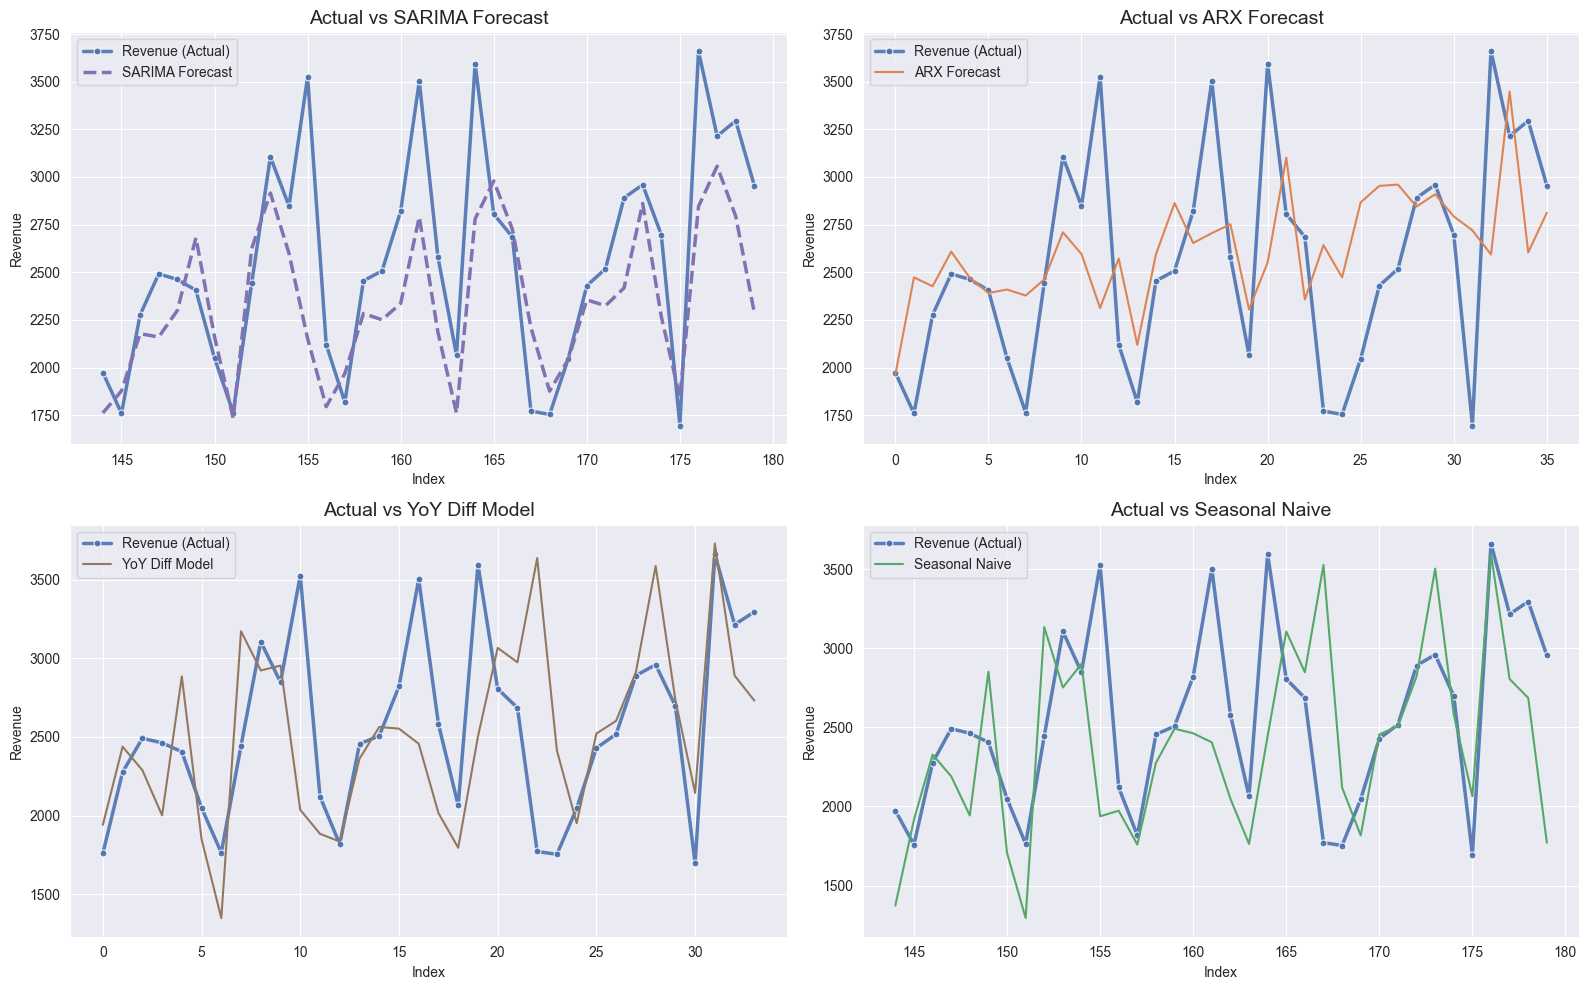

In [242]:
plt.figure(figsize=(16, 10))

rev_style = dict(
    color=palette[0],     # blue
    marker="o",
    linewidth=2.5,
    markersize=5,
    alpha=0.9,
    zorder=2
)

sarima_style = dict(
    color=palette[4],     # red
    linewidth=2.5,
    linestyle="--",
    alpha=1.0,
    zorder=3
)

# 1. SARIMA
plt.subplot(2, 2, 1)
sns.lineplot(
    x=y_test.index, 
    y=y_test.values, 
    label="Revenue (Actual)", 
    **rev_style
)
sns.lineplot(
    x=y_test.index, 
    y=y_forecast_sarima, 
    label="SARIMA Forecast", 
    **sarima_style
)
plt.title("Actual vs SARIMA Forecast", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 2. ARX Model
plt.subplot(2, 2, 2)
sns.lineplot(
    x=range(len(y_test)), 
    y=y_test_arx.values, 
    label="Revenue (Actual)", 
    **rev_style
)
sns.lineplot(
    x=range(len(y_pred)), 
    y=y_pred_arx, 
    label="ARX Forecast", 
    color=palette[1]
)
plt.title("Actual vs ARX Forecast", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 3. Revenue_from_yoy
plt.subplot(2, 2, 3)
sns.lineplot(
    data=lag_reg, 
    x=lag_reg.index, 
    y="Revenue", 
    label="Revenue (Actual)", 
    **rev_style
)
sns.lineplot(
    data=lag_reg, 
    x=lag_reg.index, 
    y="Revenue_from_yoy",
    label="YoY Diff Model", 
    color=palette[5]
)
plt.title("Actual vs YoY Diff Model", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 4. Seasonal Naive
plt.subplot(2, 2, 4)
sns.lineplot(
    x=valid_idx, 
    y=y_test.loc[valid_idx].values, 
    label="Revenue (Actual)", 
    **rev_style
)
sns.lineplot(
    x=valid_idx, 
    y=y_forecast_naive.loc[valid_idx].values, 
    label="Seasonal Naive", 
    color=palette[2]
)
plt.title("Actual vs Seasonal Naive", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()


### Final Model Selection — Executive Summary

**Statistical Properties of the Revenue Series**

Exploratory and diagnostic analysis confirms that the Revenue series is **non-stationary in level**, exhibits **strong and stable annual seasonality**, and shows **increasing variance over time**, consistent with a growing business exposed to cyclical demand. Formal unit-root tests (ADF) fail to reject non-stationarity, while STL decomposition clearly separates a persistent trend component from pronounced seasonal effects. These properties invalidate purely non-seasonal and static regression-based models as standalone forecasting tools and motivate the explicit modeling of both **integration and seasonality**.


**Model Evaluation Framework**

A broad set of forecasting approaches was evaluated, spanning regression-based models, non-seasonal ARIMA specifications, seasonal time-series models, and a strict seasonal baseline. Model performance was assessed using a combination of **out-of-sample loss functions (MAPE, WAPE, RMSE)** and **visual forecast diagnostics**, recognizing that low average error metrics alone do not guarantee realistic or operationally reliable forecasts.

The evaluated models include:
- ARX (with exogenous drivers),
- AR-based reconstruction models (YoY-differenced revenue),
- ARIMA(1,1,1),
- SARIMA(1,1,1)(1,1,1,12),
- Seasonal Naive (lag-12 baseline).

**Quantitative Performance (Out-of-Sample)**

| Model | MAPE (%) | WAPE (%) | RMSE |
|------|----------|----------|------|
| **SARIMA(1,1,1)(1,1,1,12)** | **11.45** | **12.27** | **418.27** |
| AR (Revenue from YoY diff) | 16.34 | 14.89 | 581.17 |
| Seasonal Naive (lag 12) | 17.27 | 16.99 | 607.10 |
| ARX | 17.43 | 18.75 | 644.06 |
| ARIMA(1,1,1) | 20.11 | 21.70 | 682.83 |

The **SARIMA model clearly dominates** across all error metrics, delivering materially lower forecast errors than all competing approaches, including the mandatory Seasonal Naive benchmark.

**Visual Forecast Assessment**

Visual inspection reinforces the quantitative ranking and provides critical insight into forecast realism:

- **SARIMA** accurately tracks both the **level and seasonal turning points** of Revenue, capturing peaks and troughs with appropriate timing and magnitude.
- **ARIMA(1,1,1)** generates overly smooth trajectories, failing to reflect seasonal dynamics despite formal statistical adequacy.
- **ARX** achieves moderate average accuracy but systematically **underestimates volatility**, leading to bias during peak demand periods.
- **AR (YoY Difference)** captures directional movements but exhibits level instability and overshooting.
- **Seasonal Naive** replicates seasonality mechanically but ignores evolving trend and shock dynamics.

Several models achieve acceptable MAPE values while exhibiting poor dynamic tracking, underscoring the necessity of **visual diagnostics alongside loss functions**.

**Final Model Choice**

The **SARIMA(1,1,1)(1,1,1,12)** model is selected as the **final benchmark forecasting specification**.

Key reasons:
- Lowest MAPE, WAPE, and RMSE by a clear margin,
- Superior representation of seasonal structure and revenue volatility,
- Balanced treatment of persistence, shocks, and seasonality,
- Clear outperformance of the Seasonal Naive baseline,
- Strong alignment with FP&A requirements for robustness and interpretability.

**Final Conclusion**

Seasonality is a first-order structural feature of the Revenue series and must be modeled explicitly. Regression-based models (ARX, ElasticNet) remain valuable for **economic interpretation and driver analysis**, but are not suitable as standalone forecasting tools. Non-seasonal ARIMA models are insufficient for monthly data with strong annual cycles.

The **SARIMA(1,1,1)(1,1,1,12)** model provides the best overall trade-off between accuracy, stability, and dynamic realism and is therefore adopted as the **official univariate forecasting model**. Combined with regression-based diagnostics for business insight, this framework delivers both **predictive rigor and managerial relevance**, consistent with FP&A best practices.

### Final FP&A Considerations — Diagnostic Insights and Business Implications

**Structural Properties of the Revenue Series**

Exploratory and statistical diagnostics confirm that the Revenue series is **structurally non-stationary**, exhibiting a persistent growth trend, strong annual seasonality, and high temporal dependence. Formal unit-root testing (ADF) fails to reject non-stationarity, while decomposition and autocorrelation analysis reveal that both mean and variance evolve over time. These characteristics invalidate the use of static or purely non-seasonal regression models as standalone forecasting tools and require the adoption of **time-series frameworks that explicitly model trend, seasonality, and persistence**.

**Revenue Dynamics Are Structurally Volume-Driven**

Across multiple analytical approaches—including correlation analysis, regularized linear models (ElasticNet), and non-linear methods—**volume-related variables consistently emerge as the dominant structural drivers of Revenue**. While prices and marketing expenditures display positive associations with Revenue in univariate settings, their incremental explanatory power diminishes once volume effects and multicollinearity are accounted for. This indicates that topline growth is fundamentally driven by demand expansion rather than marginal pricing adjustments.

**FP&A implication:** Sustainable Revenue growth depends primarily on **volume levers**—such as demand generation, channel penetration, and conversion efficiency—rather than on isolated pricing actions.

**Pricing as a Margin Lever, Not a Primary Growth Engine**

Price variables exhibit strong cross-sectional collinearity and move largely in parallel across products and channels. Their correlation with Revenue reflects shared scale and trend effects rather than independent growth mechanisms. In multivariate and regularized settings, pricing contributes modestly to explaining Revenue variation relative to volumes.

**FP&A implication:** Pricing decisions should be evaluated mainly through their impact on **margin, mix, and profitability**, not as the primary lever for driving topline expansion.

**Marketing as an Indirect and Conditional Driver**

Marketing expenditure shows moderate and unstable direct relationships with Revenue, including coefficient instability under regularization. Its economic role becomes clearer when interpreted as an **indirect driver**, operating through volume activation, customer acquisition, and channel effectiveness rather than immediate Revenue generation.

**FP&A implication:** Marketing effectiveness should be assessed against **volume-based and funnel KPIs** (units sold, acquisition, retention, channel activation), rather than relying solely on direct Revenue attribution.

**Multicollinearity and Limits of Static Interpretation**

Severe multicollinearity across price and unit variables—confirmed by extremely high VIF values—renders coefficient-level interpretation under standard OLS unreliable, even when overall model fit appears strong. Stable economic interpretation therefore requires **regularized frameworks**, while accurate forecasting requires models that explicitly capture temporal dependence.

**FP&A implication:** Driver analysis should rely on **regularized models, sensitivity analysis, and scenario-based reasoning**, rather than naïve inspection of coefficients from static regressions.

**Implications for Forecasting and Planning**

The combined diagnostics indicate that:
- Revenue dynamics are dominated by **trend, seasonality, and persistence**;
- Volumes constitute the primary structural lever of Revenue;
- Prices and marketing act as **secondary, conditional levers**;
- The effective dimensionality of the system is lower than the raw feature count.

These insights directly inform the forecasting strategy, where **time-series models are used for projection**, while diagnosed drivers are translated into **FP&A assumptions, scenarios, and Budget vs Actuals narratives**.

**Bridge to the Forecasting Stage**

This diagnostic module establishes the **statistical and economic foundations** for model selection and planning logic. The subsequent forecasting stage operationalizes these insights into **multi-horizon projections, scenario analysis, and actionable FP&A premises**, ensuring that planning outputs are both statistically robust and economically coherent.
